# Hier-COS Output Analysis

This notebook analyzes seeded training/test artifacts in `/scratch/g.saggini1/outputs/` and compares Hier-COS variants across datasets. Each experiment is a parent directory containing `seed_<seed>` runs; curves and final metrics report the mean and sample standard deviation across those seeds.

Default setup:
- baselines: `hiercos_<dataset>_global_softmax_ce_reg_baseline_<weight>` with `equal` and `kl_leaf`
- orthogonalize-all lex runs: `hiercos_<dataset>_global_softmax_ce_reg_lex_orthogonalize_all_<mode>`
- conflict-only lex runs: `hiercos_<dataset>_global_softmax_ce_reg_lex_conflict_only_<mode>`
- coarse-first transform ablations: `hiercos_<dataset>_global_softmax_ce_reg_lex_orthogonalize_all_coarse_first_transform_<transform>`
- targeted normalization ablation: run with `model.loss=level_softmax_ce_reg` using explicit output directories

It includes:
- validation curves for `FPA`, `weighted AP`, `TICE`, and `AHD`,
- per-level validation top-down/independent accuracy curves,
- training loss comparisons (`total`, `ce`, `reg`, `kl`, and exact weighted `loss_level_*` when available),
- optional projection/gradient diagnostics when those metrics are present in logs,
- final test comparison tables with deltas versus dataset baseline.


In [41]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'configs').exists() else cwd.parent
notebook_utils_dir = repo_root / 'notebooks'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from hcast_analysis_utils import (
    HCastAnalysis as HierCosAnalysis,
    HCastAnalysisConfig as HierCosAnalysisConfig,
    resolve_project_root,
)

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [42]:
INCLUDE_BASELINES = True
INCLUDE_TOPDOWN_METRICS = False
BASELINE_COLOR = "#243ab4"

BASELINE_BY_DATASET = {
    'cifar-100': {'run_dir': 'hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf baseline'},
    'cub-200-2011': {'run_dir': 'hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf baseline'},
    'fgvc-aircraft': {'run_dir': 'hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf baseline'},
}

MANUAL_RUNS = [
    # Equal-weight non-lex baselines
    # {'run_dir': 'hiercos_cifar100_global_softmax_ce_reg_baseline_equal', 'label': 'Hier-COS global softmax equal baseline'},
    # {'run_dir': 'hiercos_cub200_global_softmax_ce_reg_baseline_equal', 'label': 'Hier-COS global softmax equal baseline'},
    # {'run_dir': 'hiercos_aircraft_global_softmax_ce_reg_baseline_equal', 'label': 'Hier-COS global softmax equal baseline'},

    
    # level-softmax-ce-reg
    # {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS level softmax kl_leaf baseline'},
    # {'run_dir': 'hiercos_cub200_level_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS level softmax kl_leaf baseline'},
    # {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS level softmax kl_leaf baseline'},
    
    # {'run_dir': 'hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS global softmax kl_leaf_identity baseline'},
    # {'run_dir': 'hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS global softmax kl_leaf_identity baseline'},
    # {'run_dir': 'hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS global softmax kl_leaf_identity baseline'},
    # level-softmax-ce-reg identity
    # {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS level softmax kl_leaf_identity baseline'},
    # {'run_dir': 'hiercos_cub200_level_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS level softmax kl_leaf_identity baseline'},
    # {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS level softmax kl_leaf_identity baseline'},

    # {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_baseline_kl_leaf_d512_identity', 'label': 'Hier-COS level softmax kl_leaf d512 identity baseline'},
    # {'run_dir': 'hiercos_cub200_level_softmax_ce_reg_baseline_kl_leaf_d512_identity', 'label': 'Hier-COS level softmax kl_leafv d512 identity baseline'},
    # {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_baseline_kl_leaf_d512_identity', 'label': 'Hier-COS level softmax kl_leaf d512 identity baseline'},
    
    # global-softmax Orthogonalize-all lex runs 
    *[
        {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_orthogonalize_all_{mode}',
         'label': f'Hier-COS global softmax {mode} orthogonalize_all'}
        for dataset in ('cifar100', 'cub200', 'aircraft')
        for mode in ('coarse_first', '')
    ],
    # *[
    #     {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_orthogonalize_all_{mode}_identity',
    #      'label': f'Hier-COS global softmax {mode} orthogonalize_all identity'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft')
    #     for mode in ('coarse_first', '')
    # ],
    # *[
    #     {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_orthogonalize_all_{mode}_kl_leaf',
    #      'label': f'Hier-COS global softmax {mode} orthogonalize_all kl_leaf'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft')
    #     for mode in ('coarse_first', '')
    # ],
    # level-softmax Orthogonalize-all lex runs
    *[
        {'run_dir': f'hiercos_{dataset}_level_softmax_ce_reg_lex_orthogonalize_all_{mode}',
         'label': f'Hier-COS level softmax {mode} orthogonalize_all'}
        for dataset in ('cifar100', 'cub200', 'aircraft')
        for mode in ('coarse_first', '')
    ],
    # *[
    #     {'run_dir': f'hiercos_{dataset}_level_softmax_ce_reg_lex_orthogonalize_all_{mode}_identity',
    #      'label': f'Hier-COS level softmax {mode} orthogonalize_all identity'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft')
    #     for mode in ('coarse_first', '')
    # ],
    # {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_projection_identity', 'label': 'Hier-COS level softmax projection identity'},
    # {'run_dir': 'hiercos_cub200_level_softmax_ce_reg_projection_identity', 'label': 'Hier-COS level softmax projection identity'},
    # {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_projection_identity', 'label': 'Hier-COS level softmax projection identity'},

    #{'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_projection_d512_identity', 'label': 'Hier-COS level softmax d512 projection identity'},
    #{'run_dir': 'hiercos_cub200_level_softmax_ce_reg_projection_d512_identity', 'label': 'Hier-COS level softmax d512 projection identity'},
    #{'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_projection_d512_identity', 'label': 'Hier-COS level softmax d512 projection identity'},

    #{'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_projection_d512_kl_leaf_identity', 'label': 'Hier-COS level softmax projection 512 identity kl_leaf'}, 
    #{'run_dir': 'hiercos_cub200_level_softmax_ce_reg_projection_d512_kl_leaf_identity', 'label': 'Hier-COS level softmax projection 512 identity kl_leaf'}, 
    #{'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_projection_d512_kl_leaf_identity', 'label': 'Hier-COS level softmax projection 512 identity kl_leaf'}, 

    # {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_projection_noadapt_kl_leaf_identity', 'label': 'Hier-COS level softmax projection_noadapt identity kl_leaf'}, 
    # {'run_dir': 'hiercos_cub200_level_softmax_ce_reg_projection_noadapt_kl_leaf_identity', 'label': 'Hier-COS level softmax projection_noadapt identity kl_leaf'}, 
    # {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_projection_noadapt_kl_leaf_identity', 'label': 'Hier-COS level softmax projection_noadapt identity kl_leaf'},
    
    # {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_projection_noadapt_d512_kl_leaf_identity', 'label': 'Hier-COS level softmax projection_noadapt d512 identity kl_leaf'}, 
    # {'run_dir': 'hiercos_cub200_level_softmax_ce_reg_projection_noadapt_d512_kl_leaf_identity', 'label': 'Hier-COS level softmax projection_noadapt d512 identity kl_leaf'}, 
    # {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_projection_noadapt_d512_kl_leaf_identity', 'label': 'Hier-COS level softmax projection_noadapt d512 identity kl_leaf'}, 

    # {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_projection_noadapt_identity', 'label': 'Hier-COS level softmax projection_noadapt identity'}, 
    # {'run_dir': 'hiercos_cub200_level_softmax_ce_reg_projection_noadapt_identity', 'label': 'Hier-COS level softmax projection_noadapt identity'}, 
    # {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_projection_noadapt_identity', 'label': 'Hier-COS level softmax projection_noadapt identity'},  

    # {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_projection_noadapt_d512_identity', 'label': 'Hier-COS level softmax projection_noadapt d512 identity'}, 
    # {'run_dir': 'hiercos_cub200_level_softmax_ce_reg_projection_noadapt_d512_identity', 'label': 'Hier-COS level softmax projection_noadapt d512 identity'}, 
    # {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_projection_noadapt_d512_identity', 'label': 'Hier-COS level softmax projection_noadapt d512 identity'}, 
    # *[
    #     {'run_dir': f'hiercos_{dataset}_level_softmax_ce_reg_lex_orthogonalize_all_{mode}_kl_leaf',
    #      'label': f'Hier-COS level softmax {mode} orthogonalize_all kl_leaf'}
    #     for dataset in ('cub200', 'aircraft')
    #     for mode in ('coarse_first', '')
    # ],

    # # Conflict-only lex runs
    # *[
    #     {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_conflict_only_{mode}',
    #      'label': f'Hier-COS global softmax {mode} conflict_only'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft')
    #     for mode in ('coarse_first', 'fine_first')
    # ],

    # Uncomment after running transform ablations.
    # *[
    #     {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_orthogonalize_all_coarse_first_{transform}',
    #      'label': f'Hier-COS global softmax coarse_first {transform}'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft')
    #     for transform in ('bn_linear', 'final_only')
    # ],
    # *[
    #     {'run_dir': f'hiercos_{dataset}_level_softmax_ce_reg_lex_orthogonalize_all_coarse_first_{transform}_kl_leaf_identity',
    #      'label': f'Hier-COS level softmax coarse_first {transform} identity'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft')
    #     for transform in ('', 'final_only')
    # ],
]

TEMPERATURE_COLOR_PALETTE = [
    '#d62728',
    '#2ca02c',
    '#ff7f0e',
    '#9467bd',
    '#8c564b',
    '#17becf',
    '#e377c2',
    '#bcbd22',
]


In [43]:
config = HierCosAnalysisConfig(
    outputs_root=OUTPUTS_ROOT,
    include_baselines=INCLUDE_BASELINES,
    include_topdown_metrics=INCLUDE_TOPDOWN_METRICS,
    baseline_color=BASELINE_COLOR,
    baseline_by_dataset=BASELINE_BY_DATASET,
    manual_runs=MANUAL_RUNS,
    temperature_color_palette=TEMPERATURE_COLOR_PALETTE,
)

analysis = HierCosAnalysis.from_config(config)
analysis.print_run_summary()


Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_lex_orthogonalize_all_
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cub200_global_softmax_ce_reg_lex_orthogonalize_all_
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_aircraft_global_softmax_ce_reg_lex_orthogonalize_all_
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cifar100_level_softmax_ce_reg_lex_orthogonalize_all_
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cub200_level_softmax_ce_reg_lex_orthogonalize_all_
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_aircraft_level_softmax_ce_reg_lex_orthogonalize_all_


[cifar-100] Hier-COS global softmax kl_leaf baseline: epochs=100, best_ind_epoch=93.66666666666667, baseline, seeds=[0, 1, 2]
[cifar-100] Hier-COS global softmax coarse_first orthogonalize_all: epochs=100, best_ind_epoch=97.0, seeds=[0, 1, 2]
[cifar-100] Hier-COS level softmax coarse_first orthogonalize_all: epochs=100, best_ind_epoch=89.33333333333333, seeds=[0, 1, 2]
[cub-200-2011] Hier-COS global softmax kl_leaf baseline: epochs=100, best_ind_epoch=71.66666666666667, baseline, seeds=[0, 1, 2]
[cub-200-2011] Hier-COS global softmax coarse_first orthogonalize_all: epochs=100, best_ind_epoch=84.0, seeds=[0, 1, 2]
[cub-200-2011] Hier-COS level softmax coarse_first orthogonalize_all: epochs=100, best_ind_epoch=78.33333333333333, seeds=[0, 1, 2]
[fgvc-aircraft] Hier-COS global softmax kl_leaf baseline: epochs=100, best_ind_epoch=70.66666666666667, baseline, seeds=[0, 1, 2]
[fgvc-aircraft] Hier-COS global softmax coarse_first orthogonalize_all: epochs=100, best_ind_epoch=63.0, seeds=[0, 1,

## Hier-COS Variants: Validation Curves (Per Dataset)

Each panel overlays both decoding modes on the **same axes**:

- color = run
- line style = mode (`topdown` solid, `independent` dashed)

Metrics shown: `FPA`, `wAP`, `TICE`, and `AHD`.


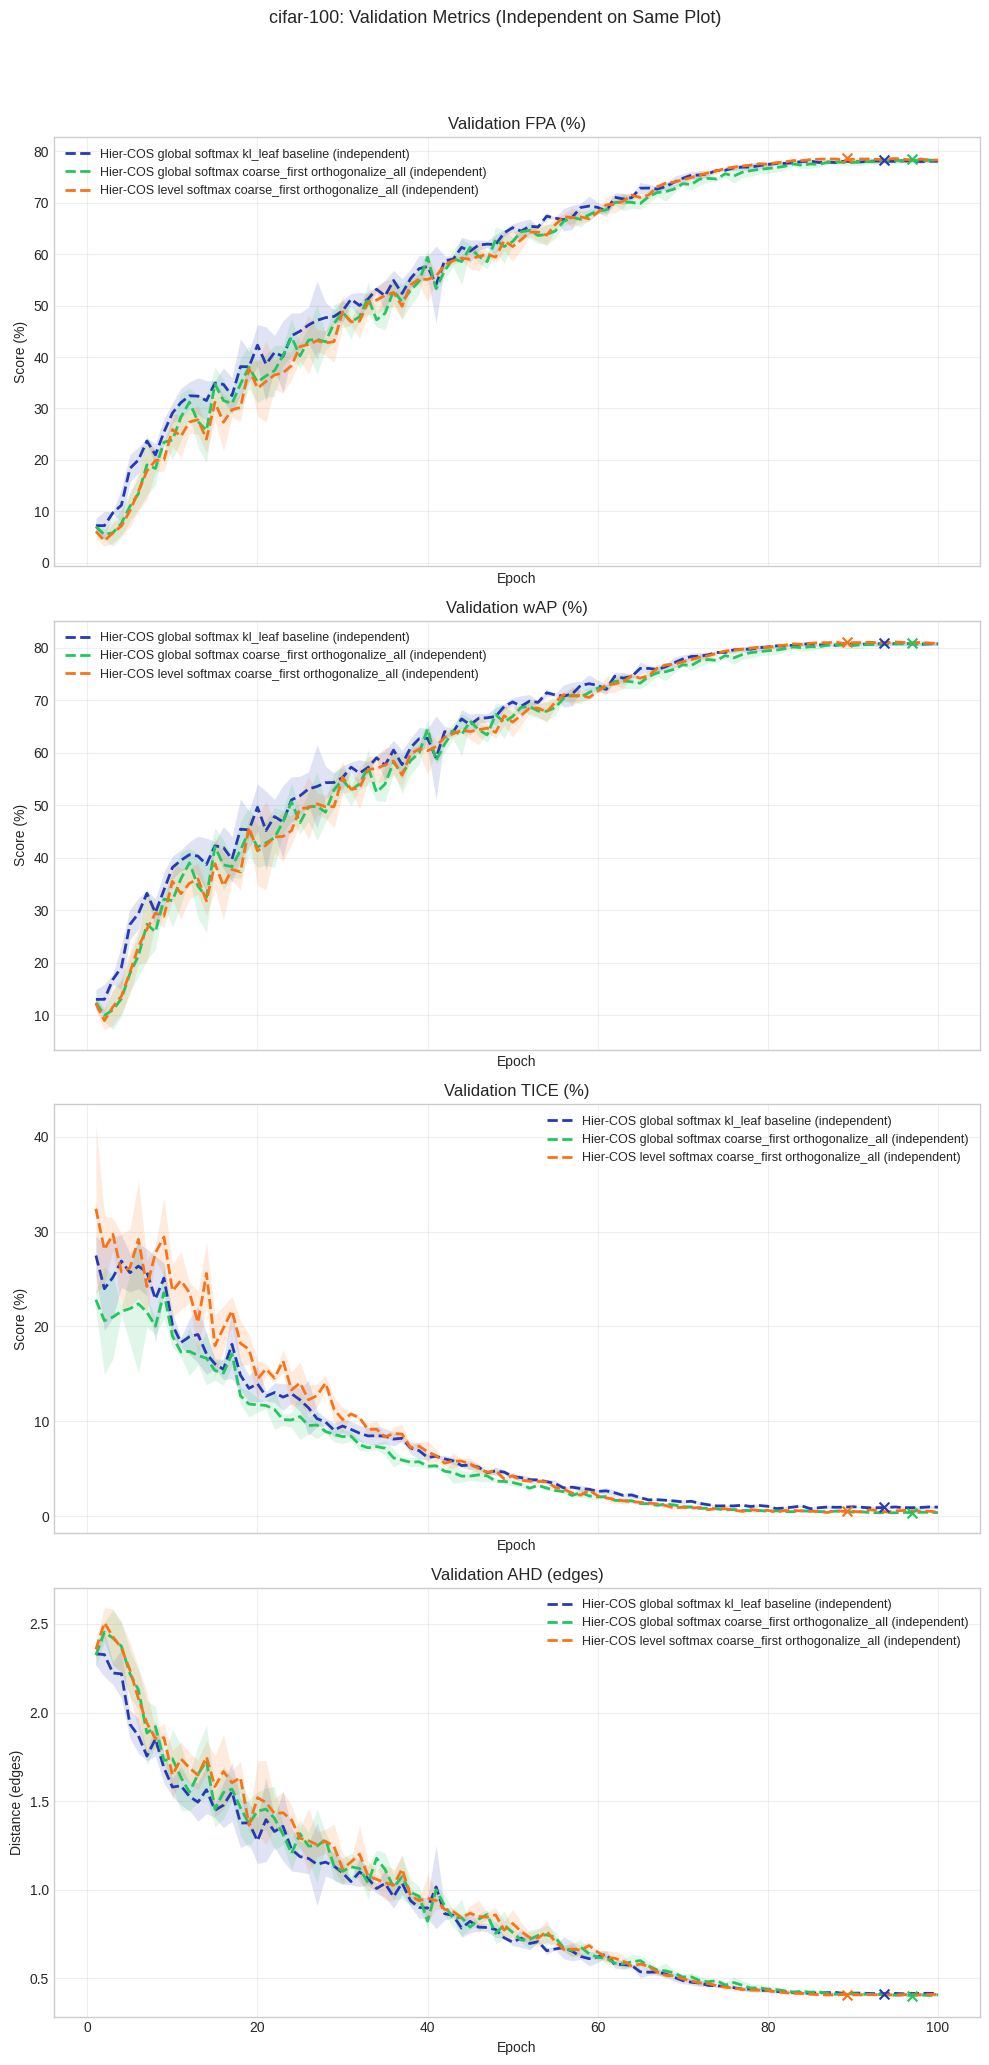

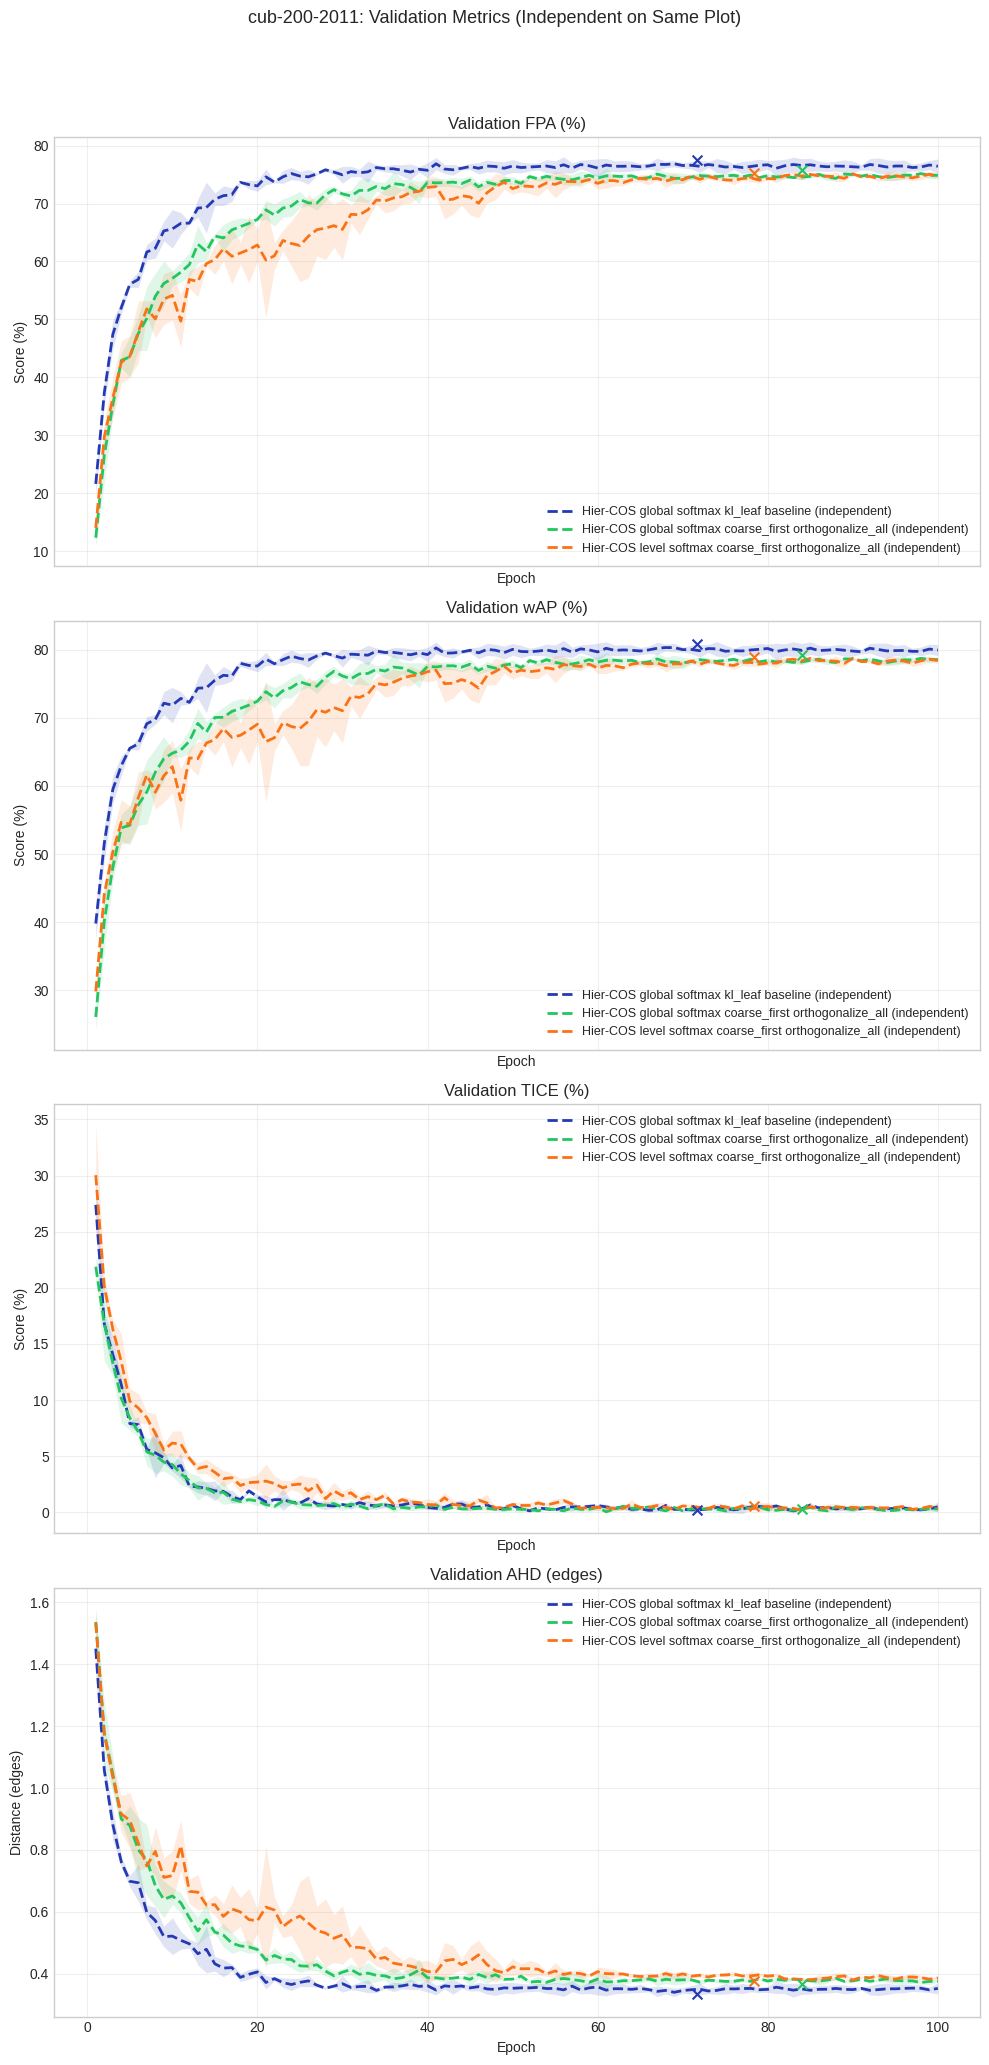

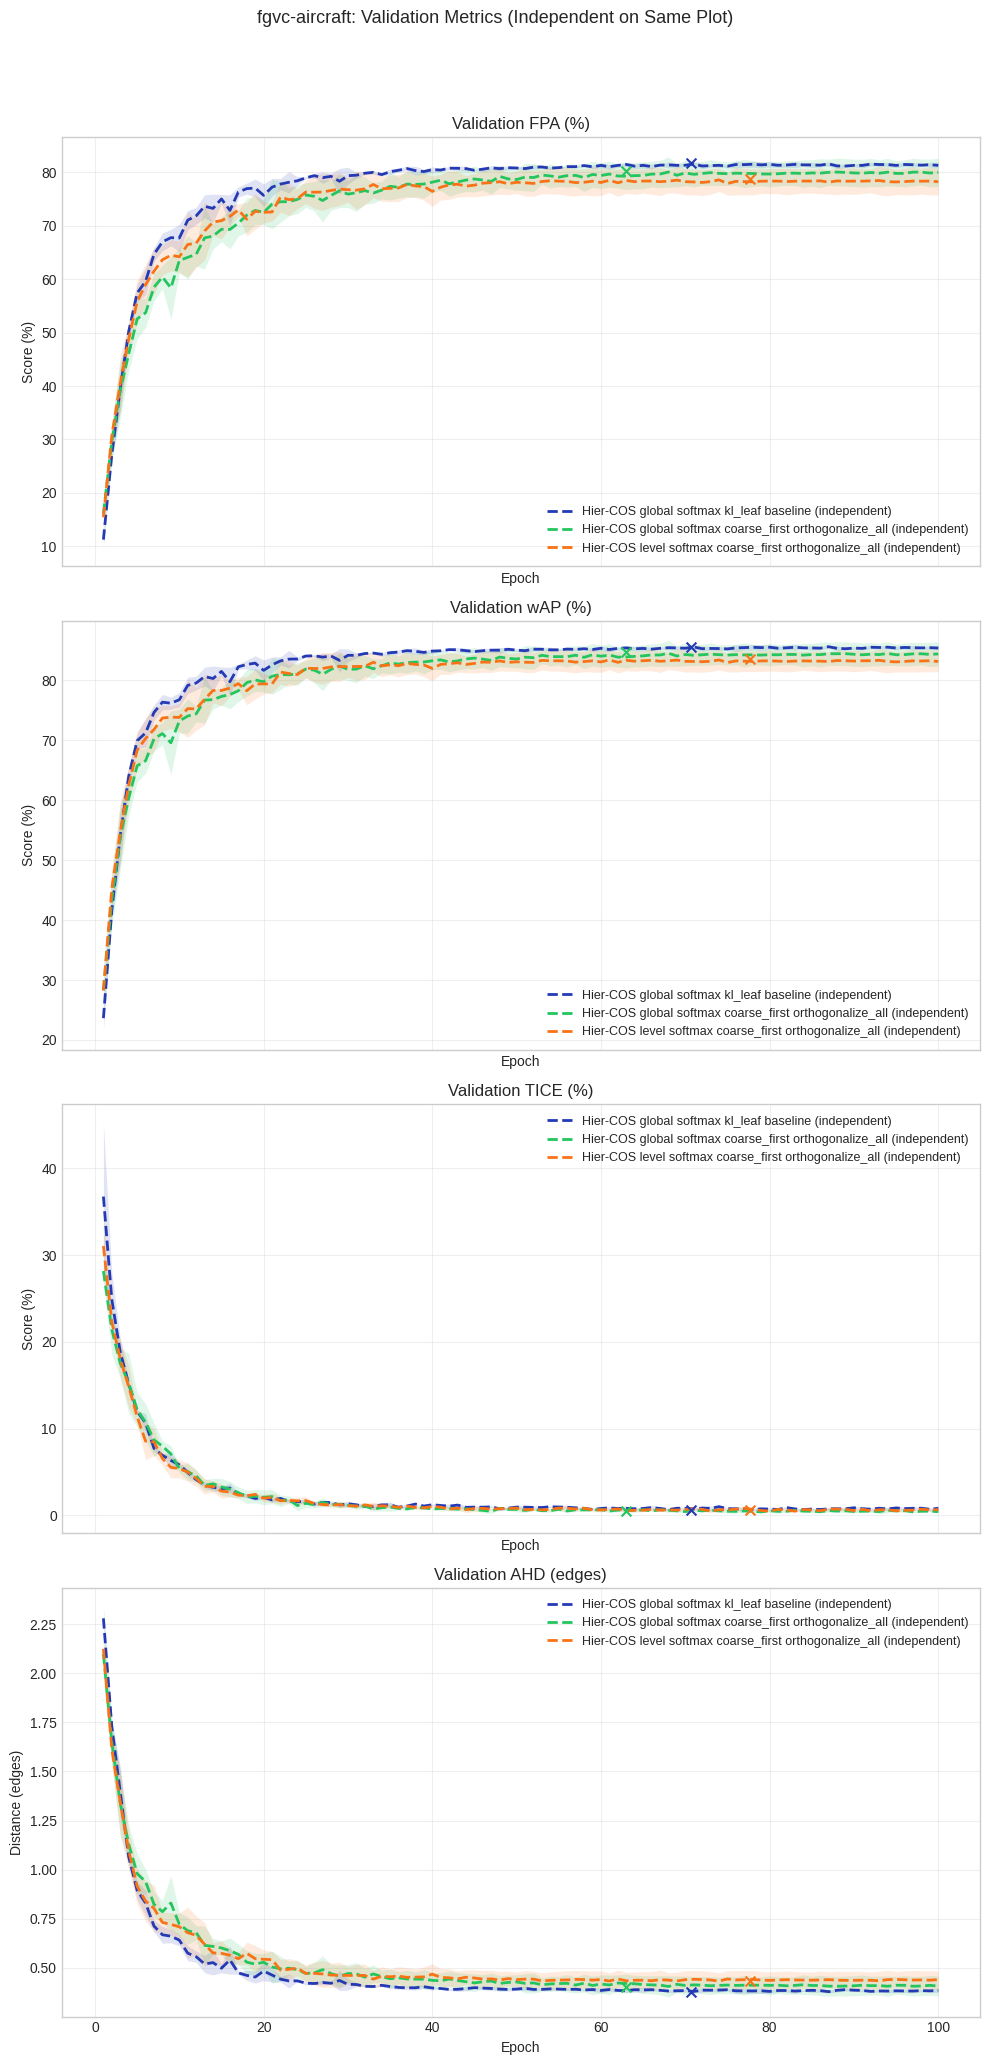

In [44]:
analysis.plot_validation_curves()


Interpretation note:
- For `FPA` and `wAP`, higher is better; for `TICE`, lower is better.
- Compare solid vs dashed lines of the same color to isolate hierarchy-enforcement effects for one run.
- Compare colors at the same line style to compare runs under the same decoding mode.

## Projection Diagnostics (If Available)

This section visualizes projection diagnostics logged in `val_metrics` and `train_metrics` (when available):
- `proj_constraint_alpha`, `proj_constraint_strength`, `proj_temperature`, `proj_mode_intrinsic_soft`

For standard Hier-COS runs these keys may be absent; in that case the section prints a per-dataset skip message.


In [45]:
analysis.plot_projection_diagnostics()


[cifar-100] No projection diagnostics found in selected runs.
[cub-200-2011] No projection diagnostics found in selected runs.
[fgvc-aircraft] No projection diagnostics found in selected runs.


## Training Loss Comparison

This section compares aggregate losses (`total`, `ce`, `reg`, and exact `kl` for `kl_reg`) and exact weighted per-level objectives (`loss_level_*`, when available).


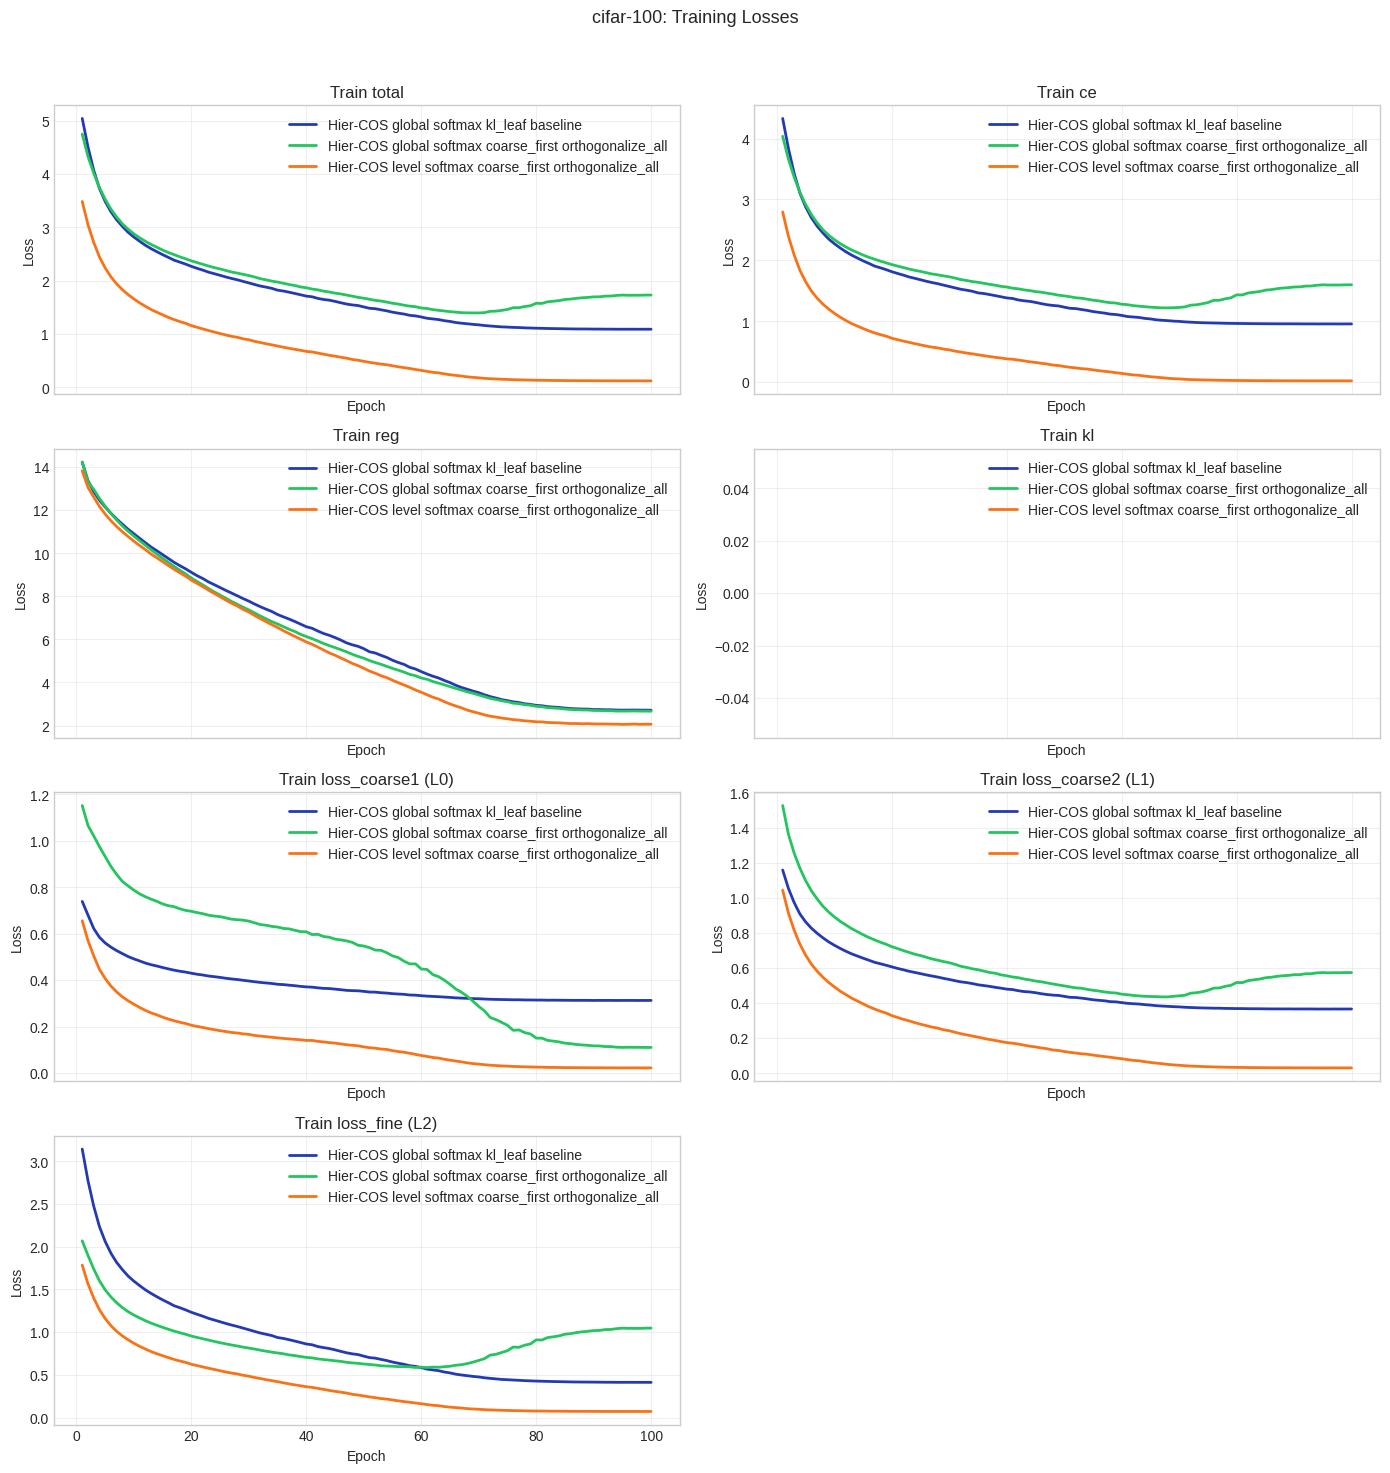

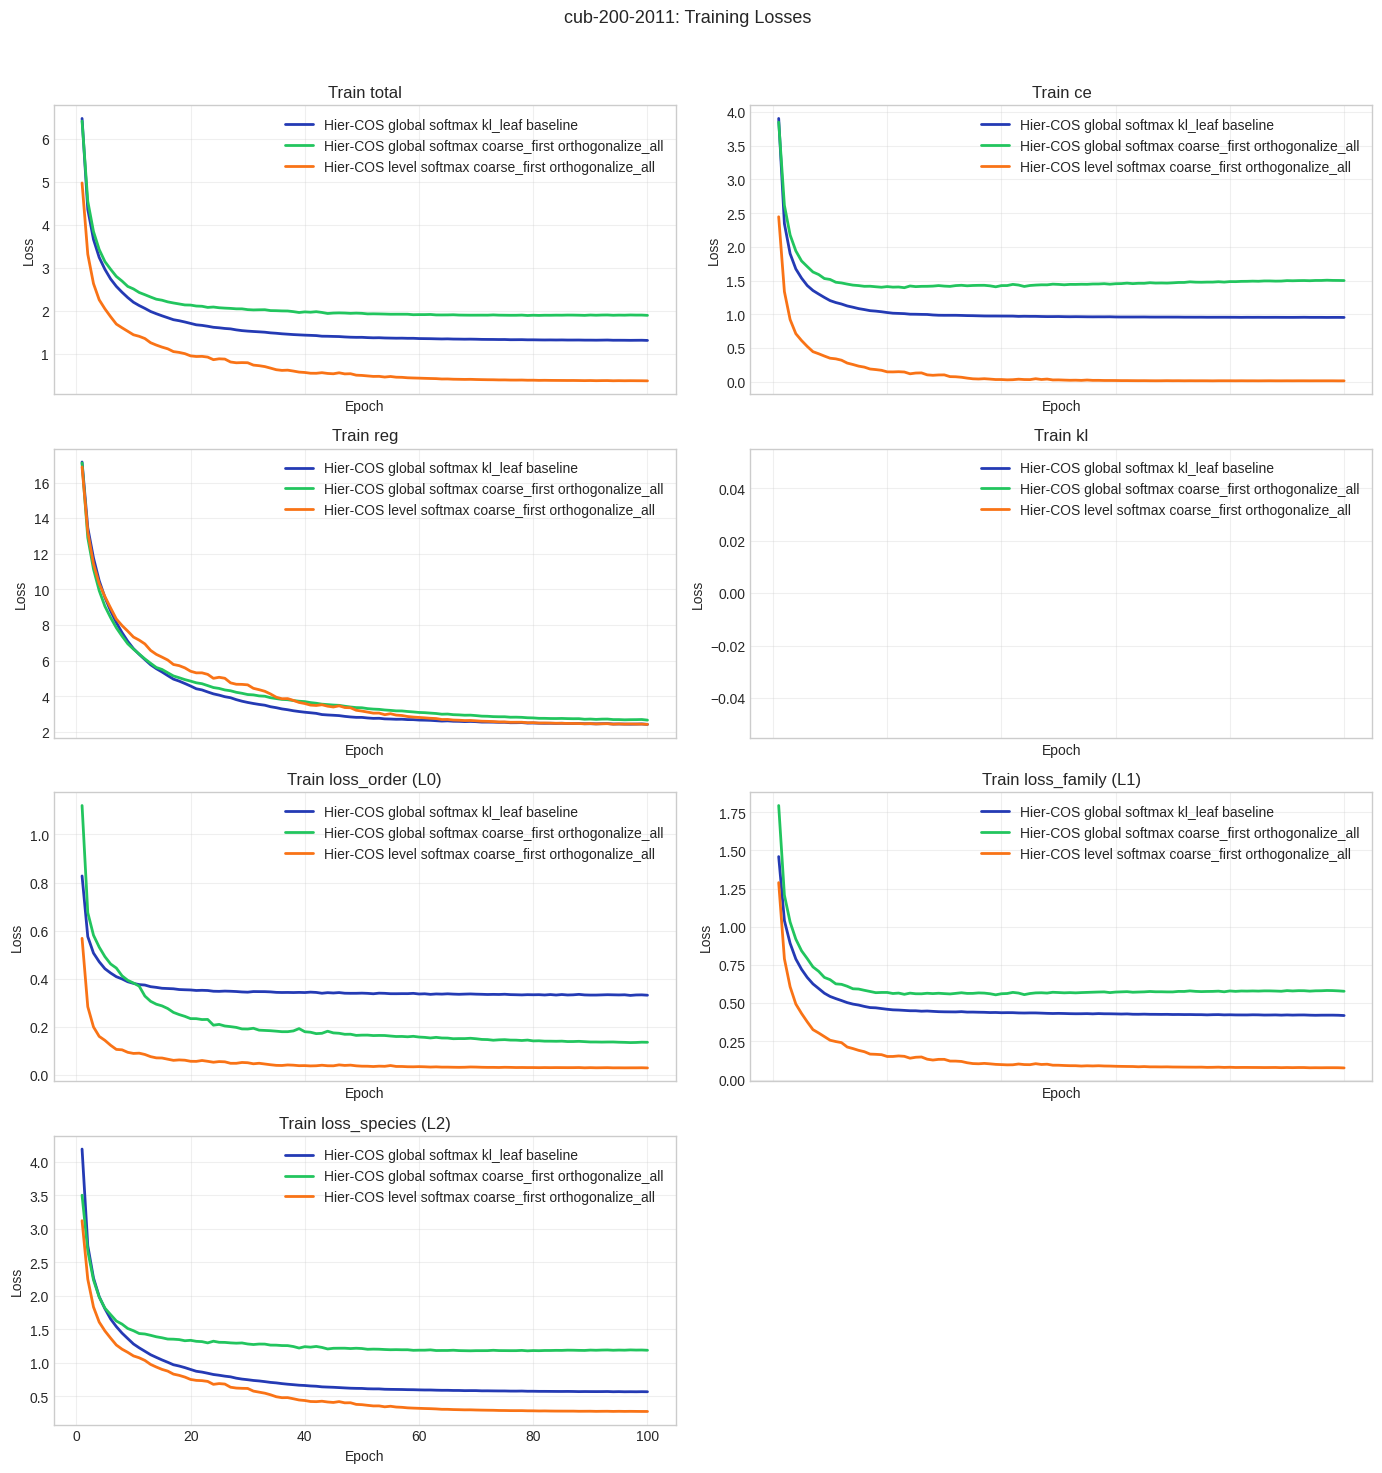

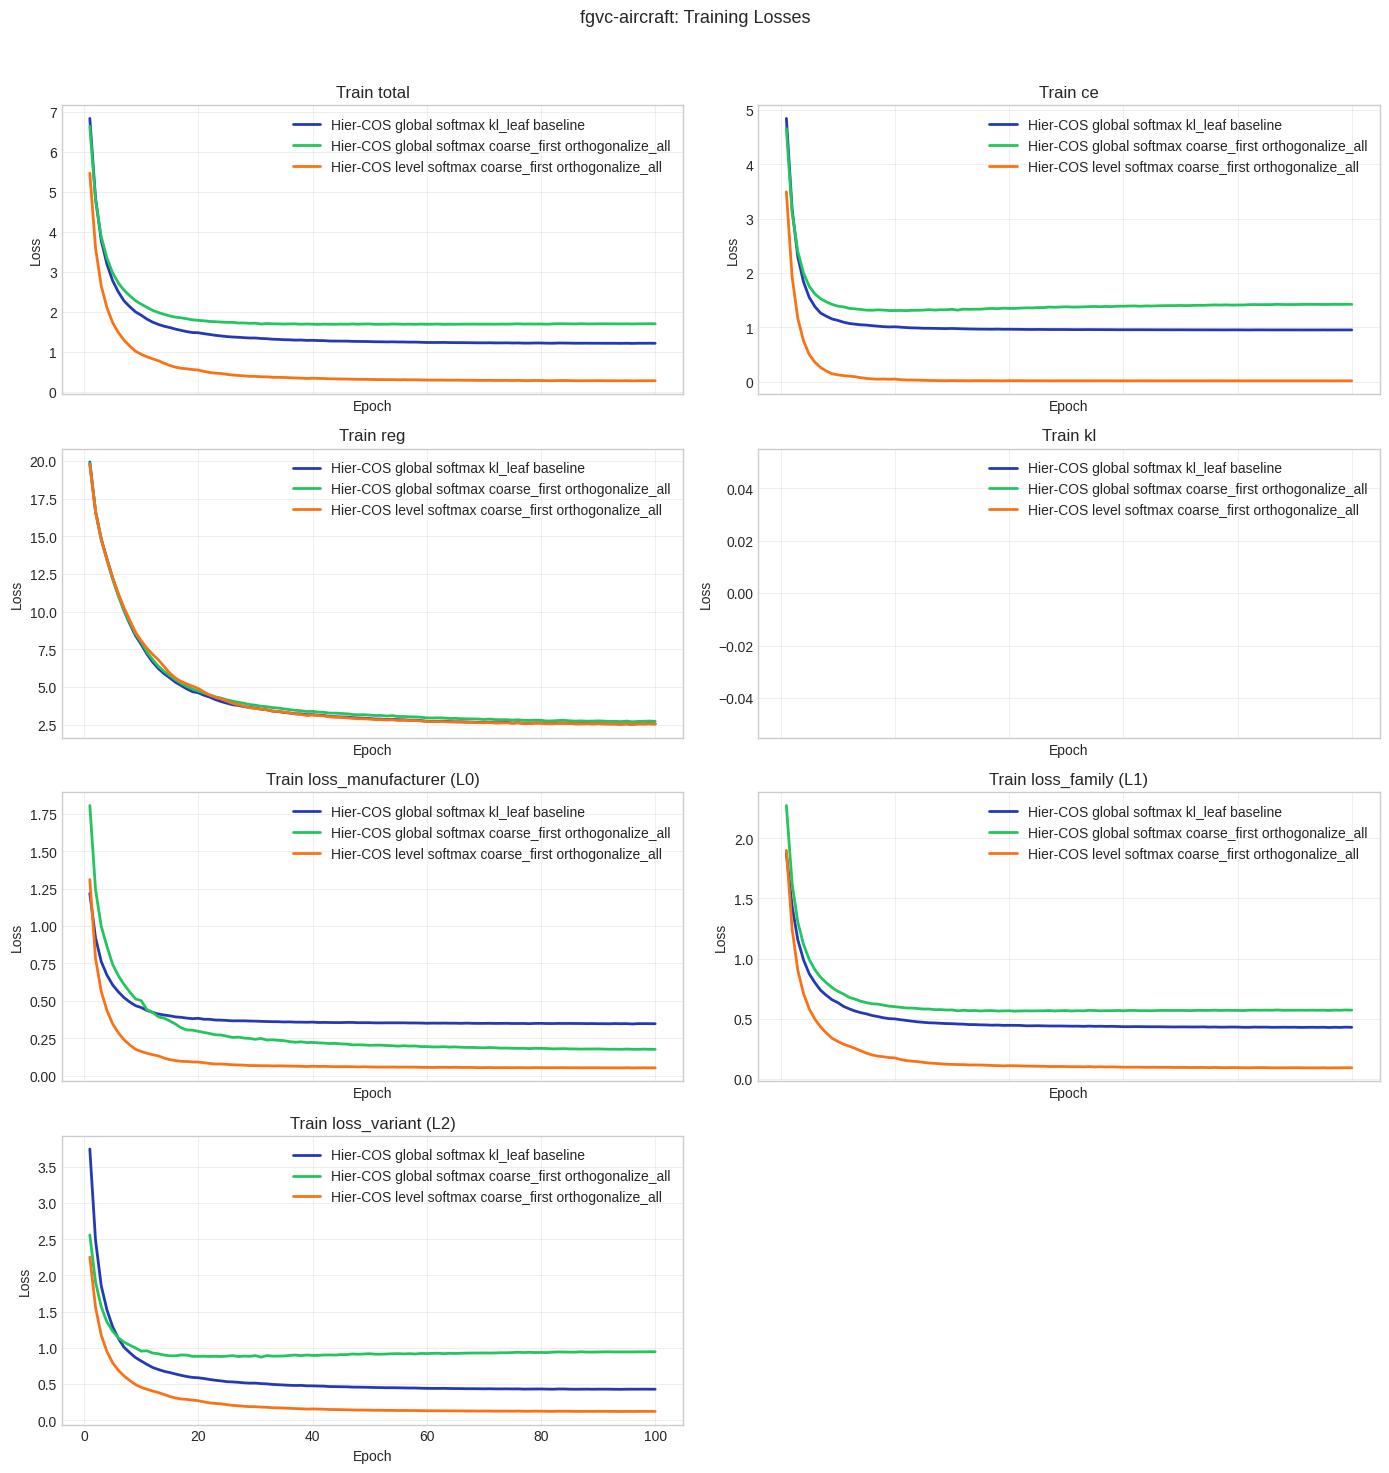

In [46]:
analysis.plot_training_losses(aggregate_loss_keys=['total', 'ce', 'reg', 'kl'])


Interpretation note:
- Lower is better for all loss curves.
- Compare `total` first for optimization behavior, then `loss_level_*` to see where depth-specific training differs.
- If one run has consistently lower shallow-level loss but much higher deep-level loss, expect weaker fine-grained accuracy and path metrics.

## Per-Run Per-Level Training Losses (Per Dataset)

Interpretation note:
- Each chart corresponds to one selected run in its dataset section.
- Lines in the same chart are all available `loss_level_*` training losses (lower is better).



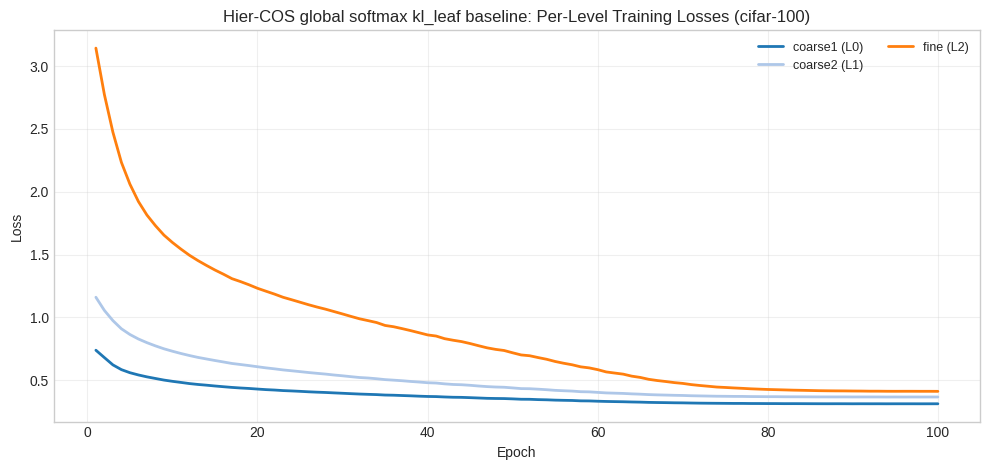

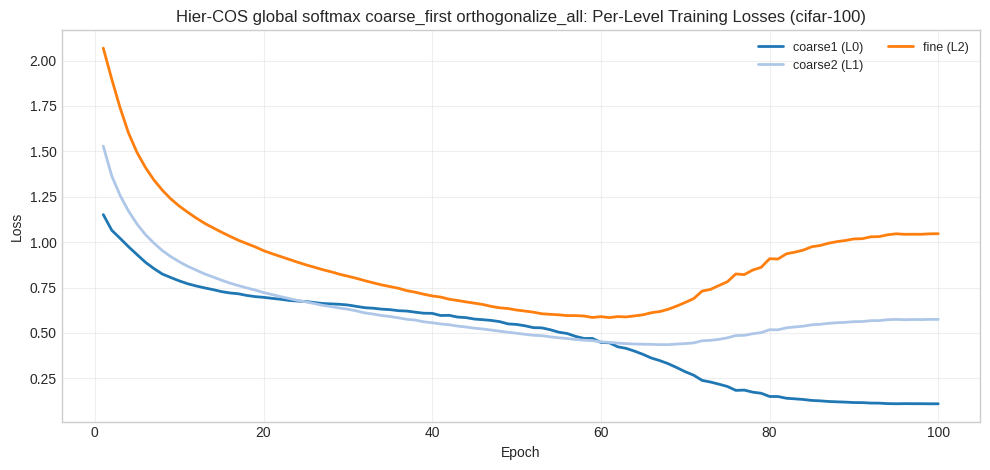

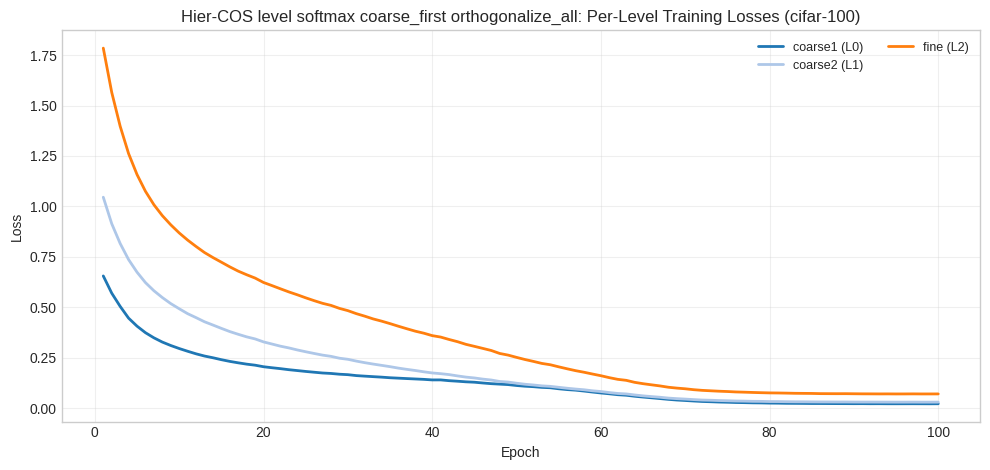

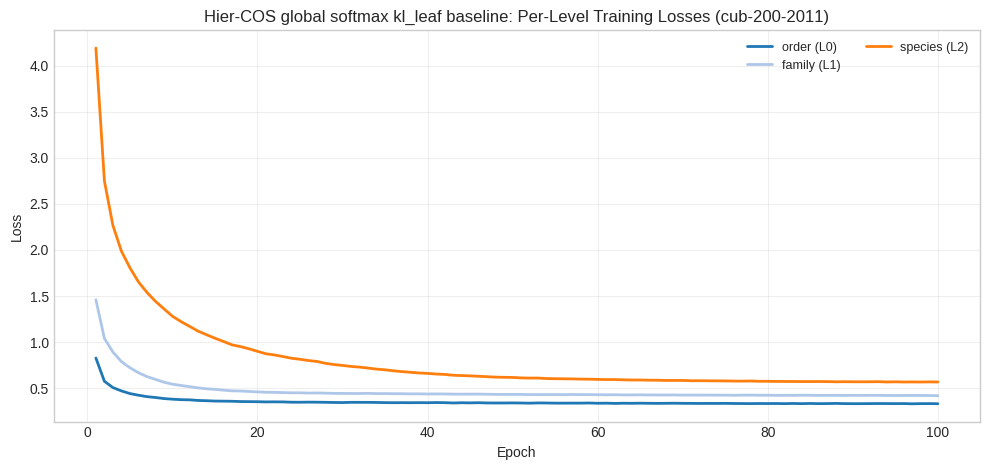

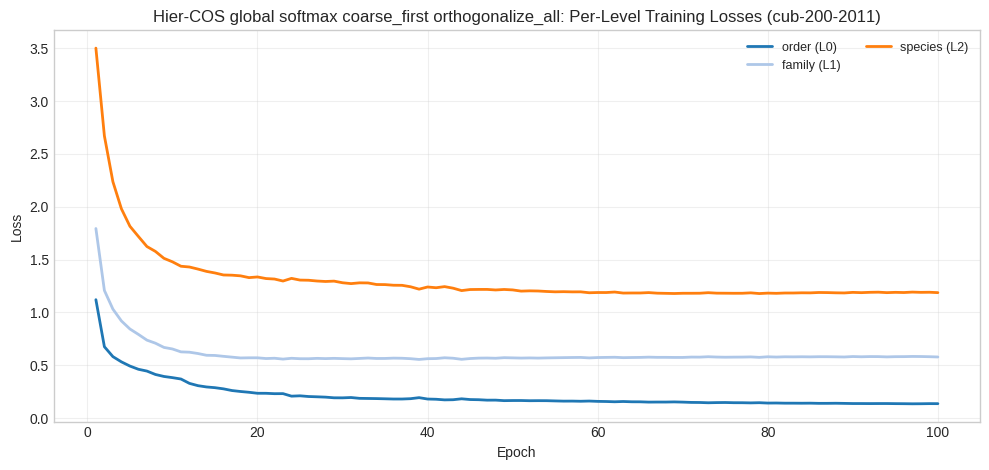

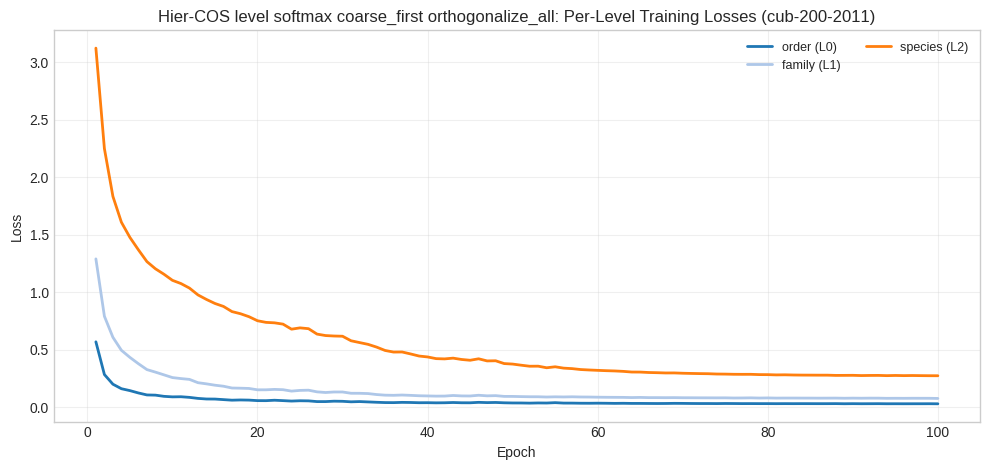

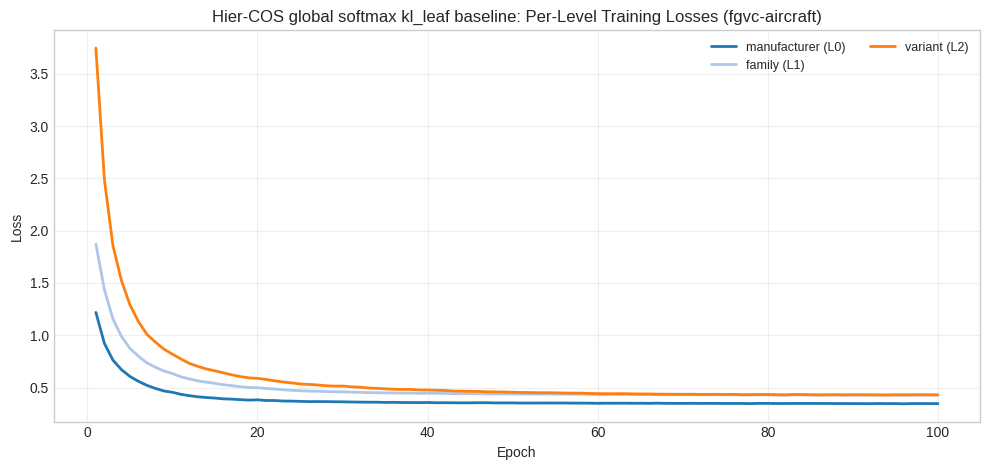

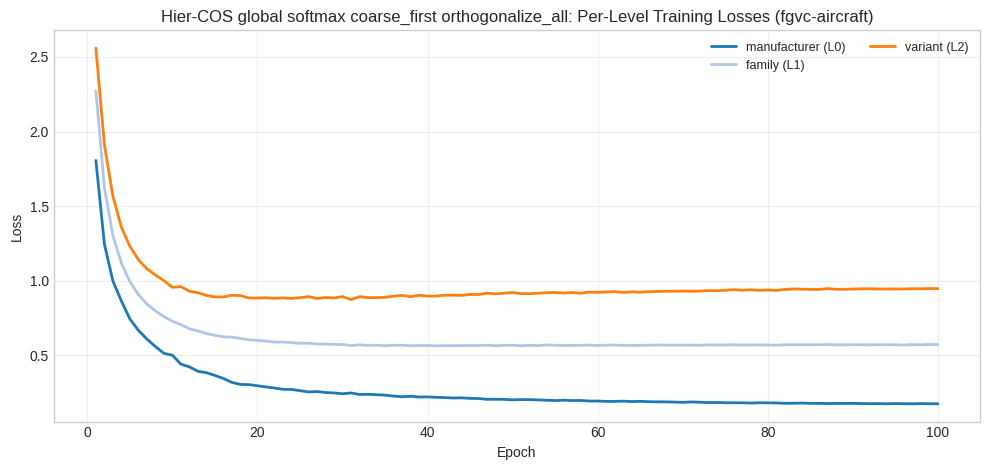

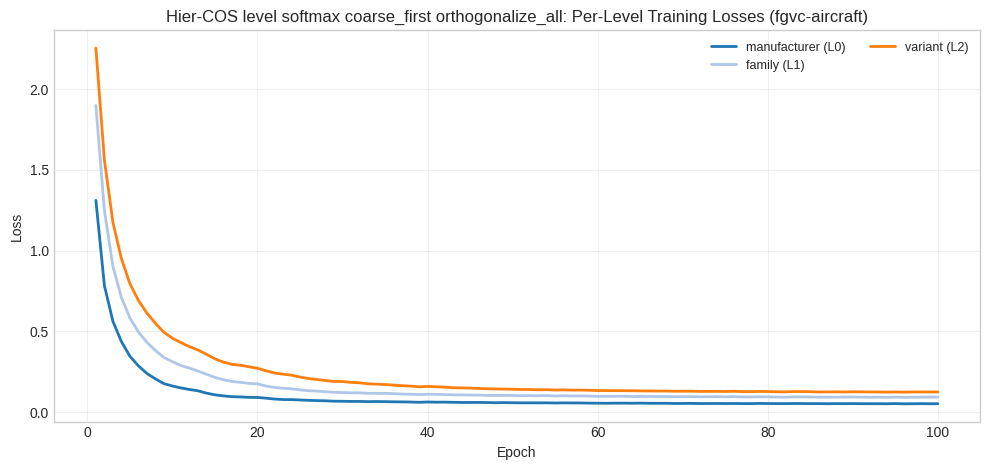

In [47]:
analysis.plot_per_run_per_level_training_losses()


## Gradient Diagnostics (Train)

This section visualizes trunk-based gradient/parameter metrics and optional projection diagnostics stored in `train_metrics` for each epoch.

For Hier-COS, many of these metrics are available only in CE/diagnostic-focused runs. If unavailable, corresponding plots are skipped automatically.


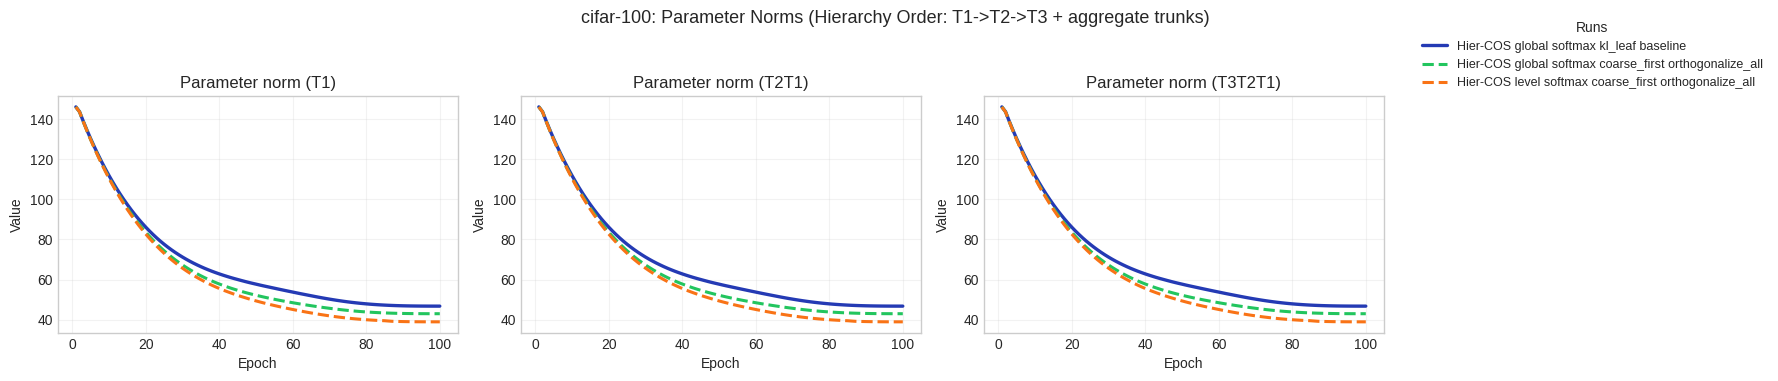

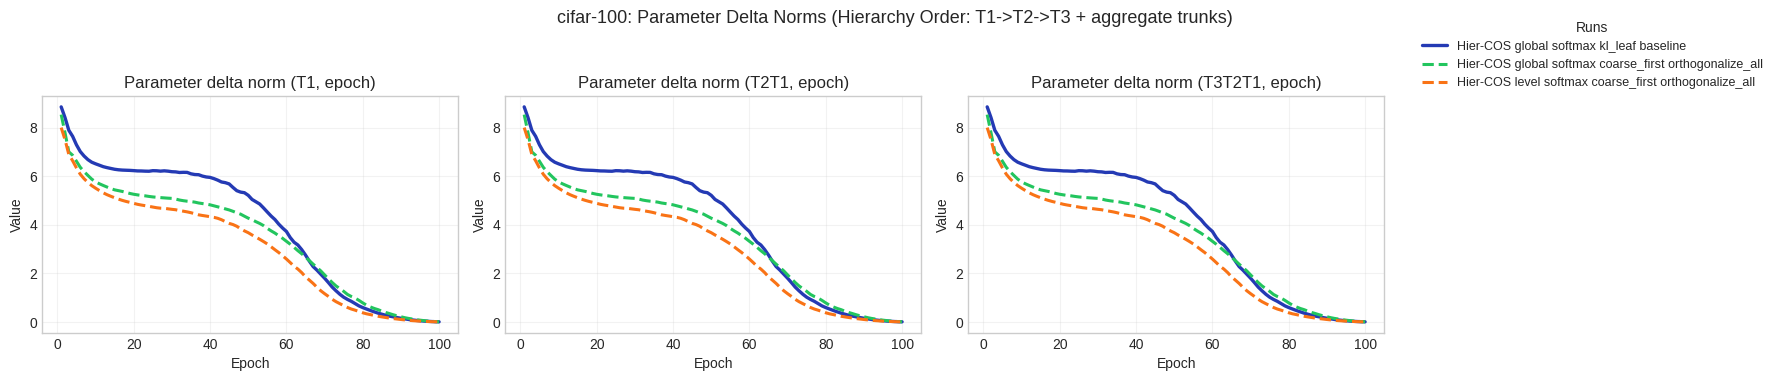

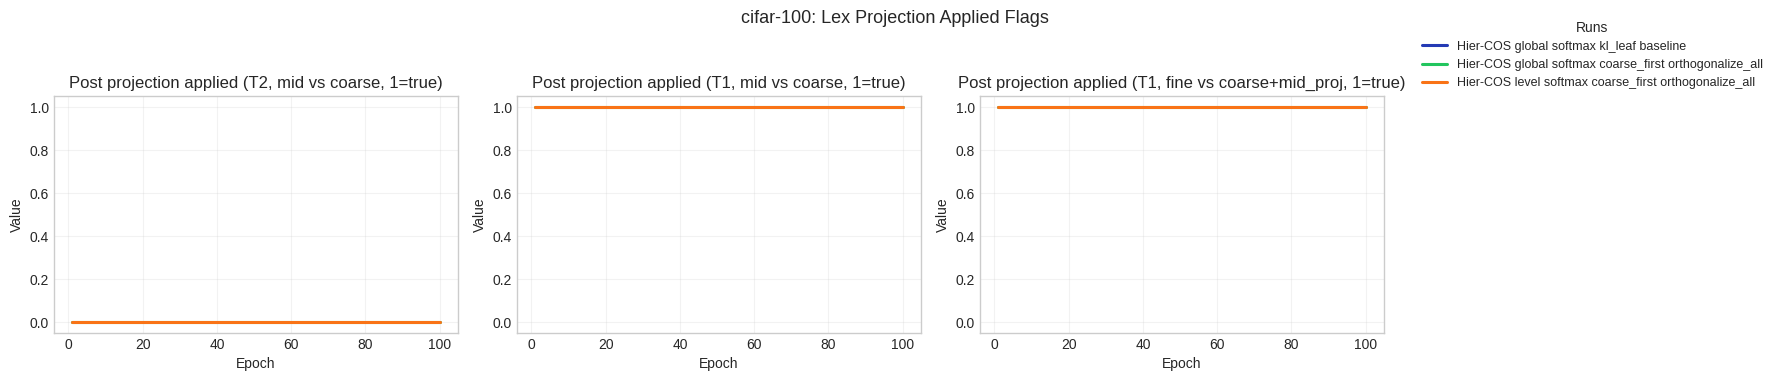

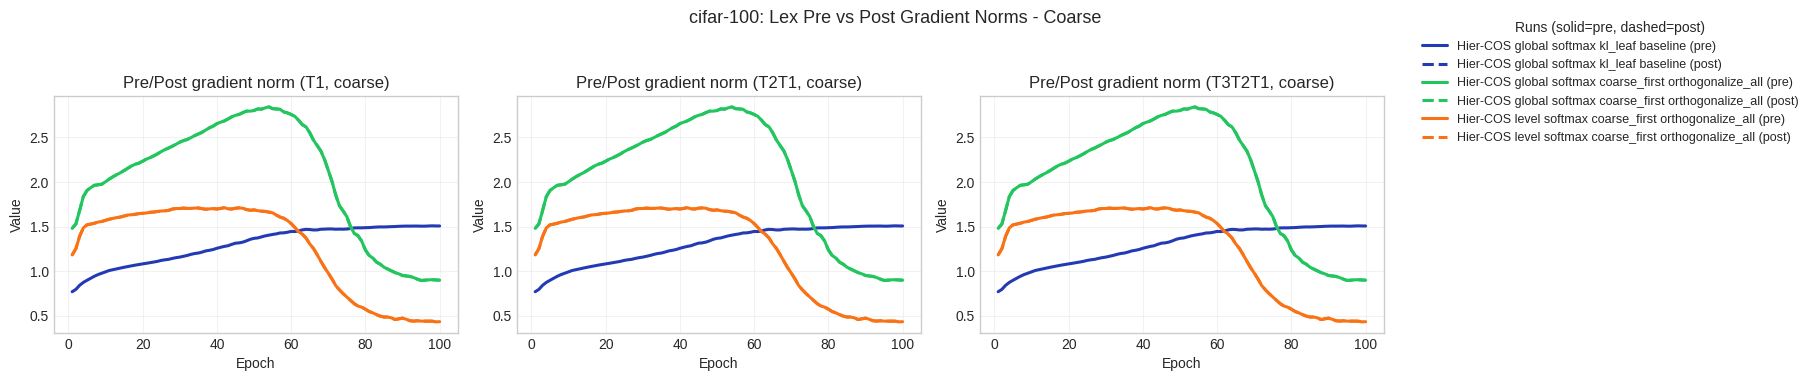

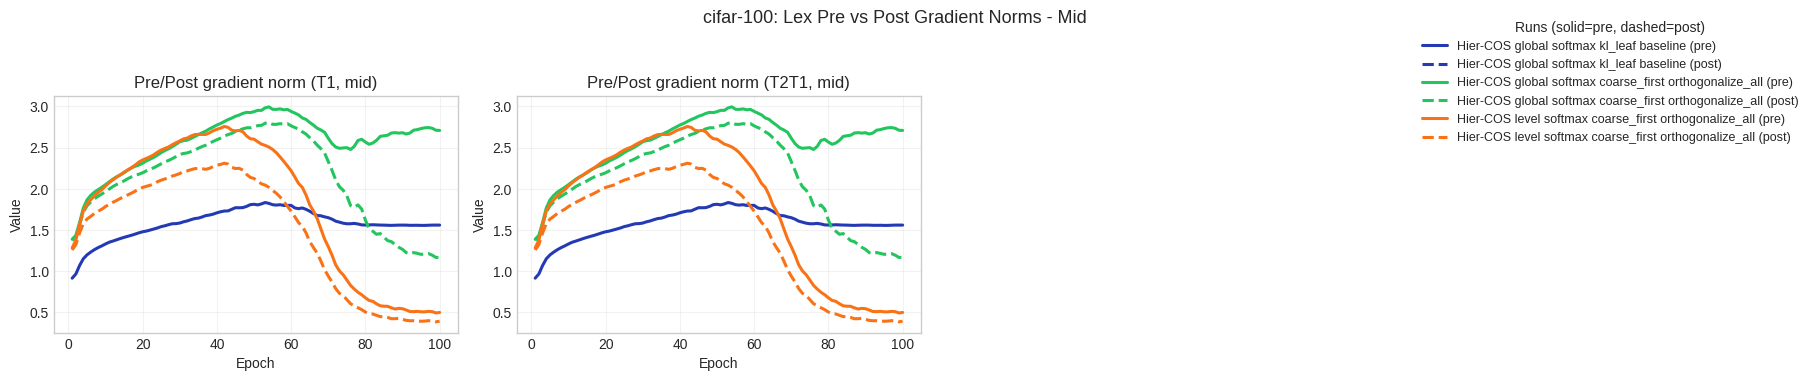

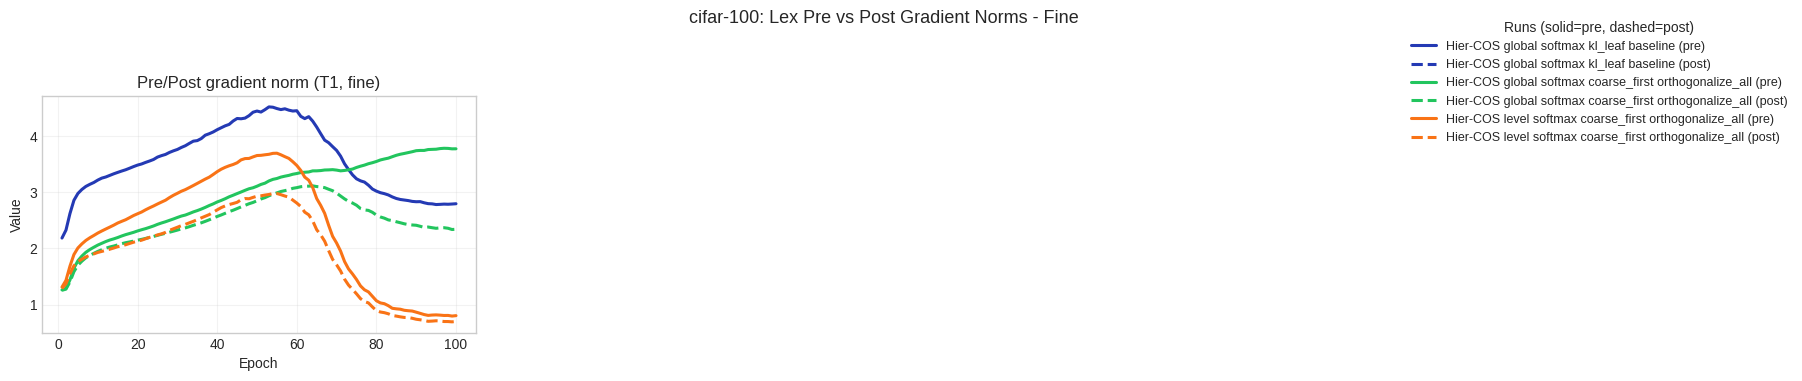

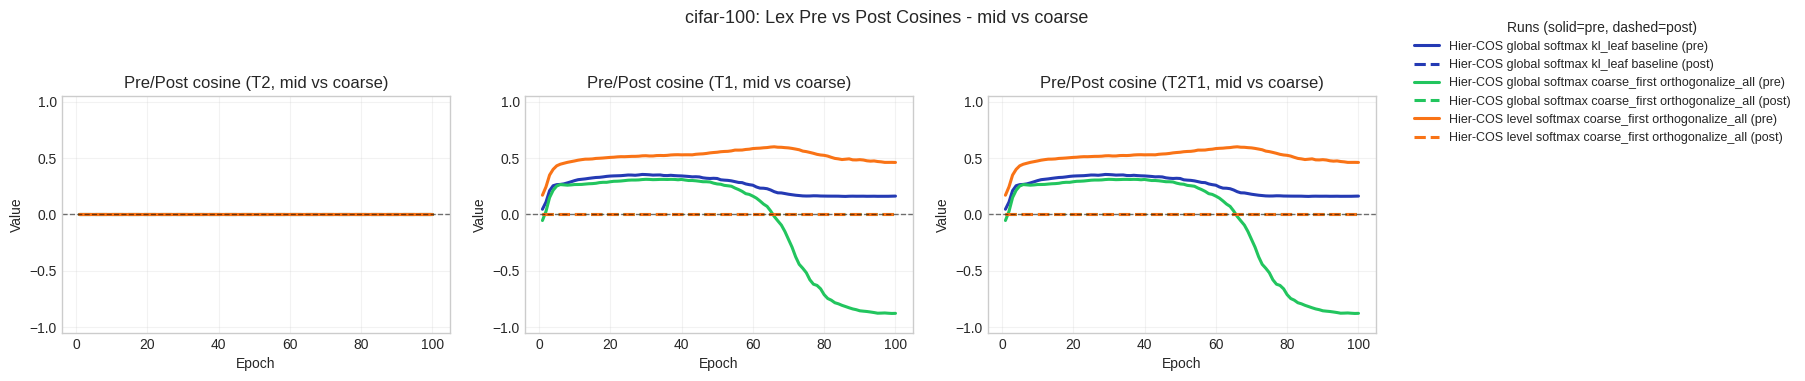

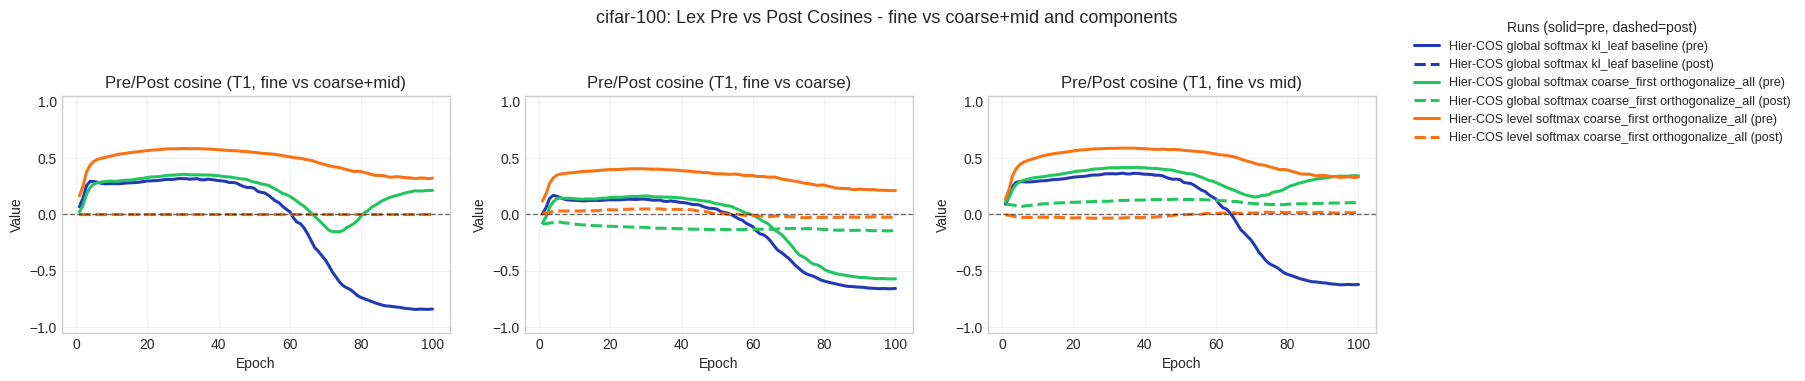

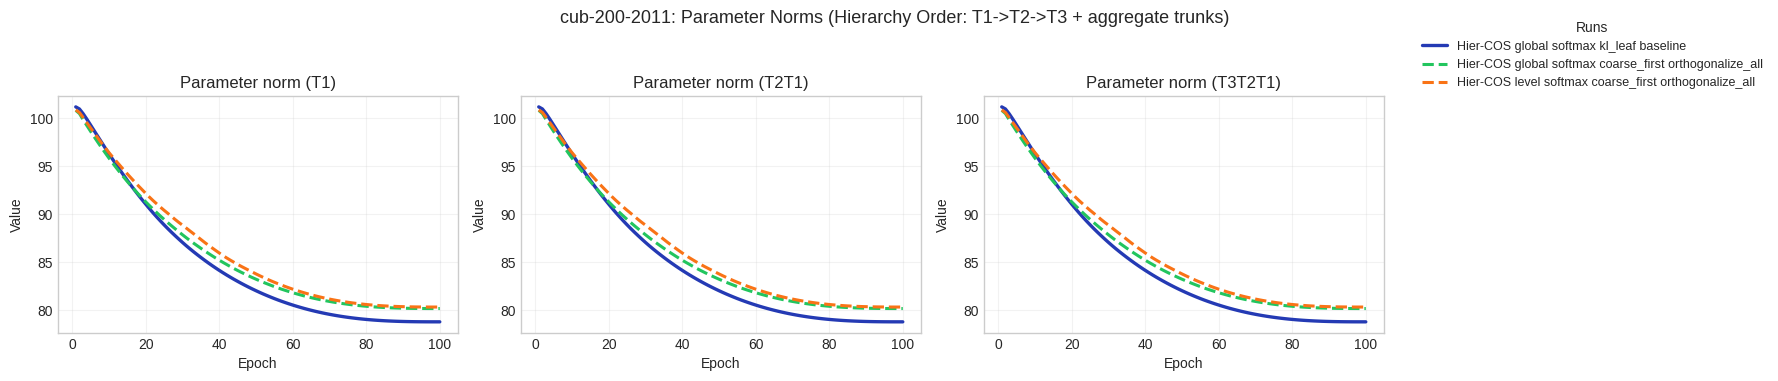

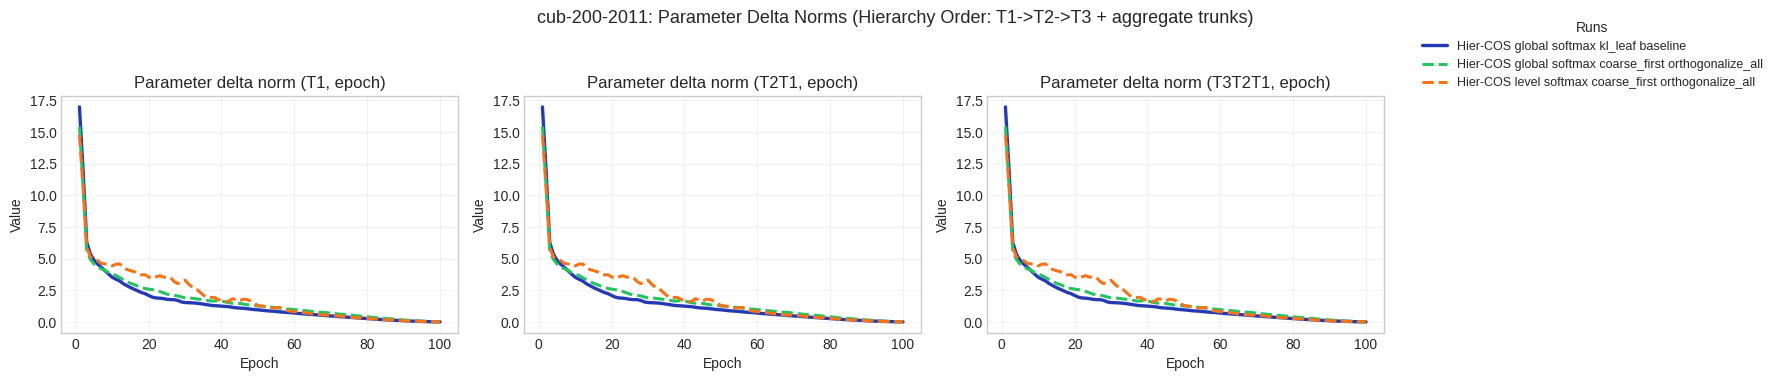

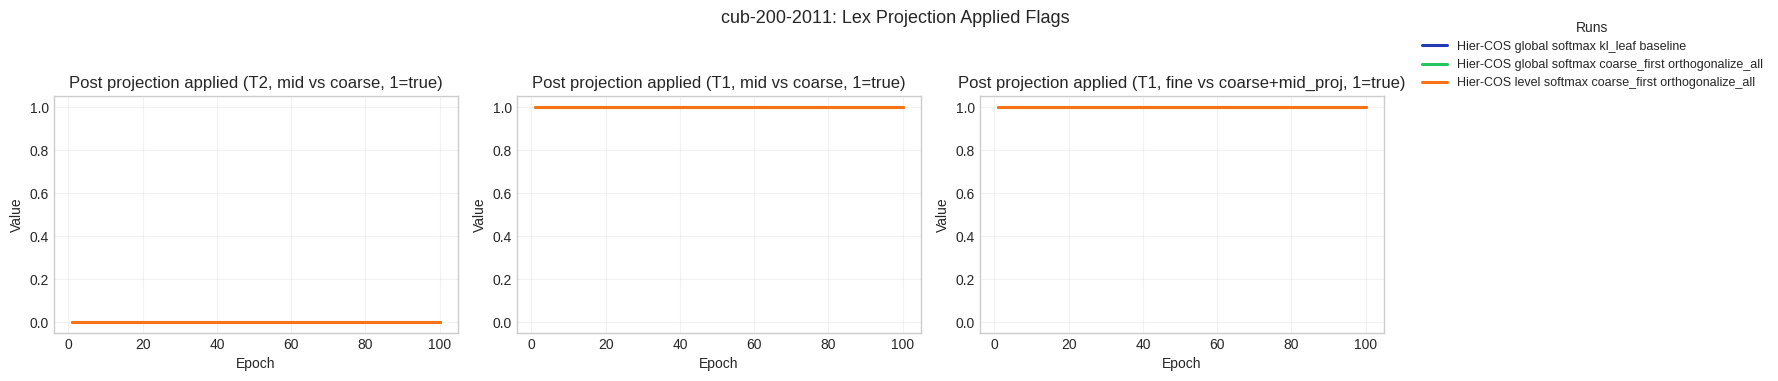

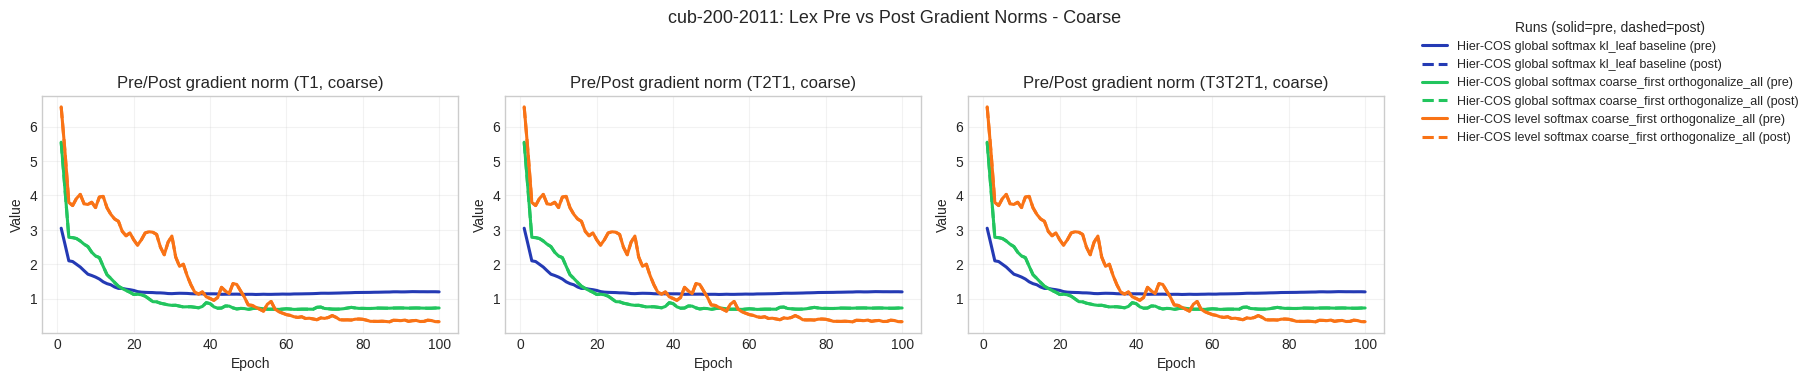

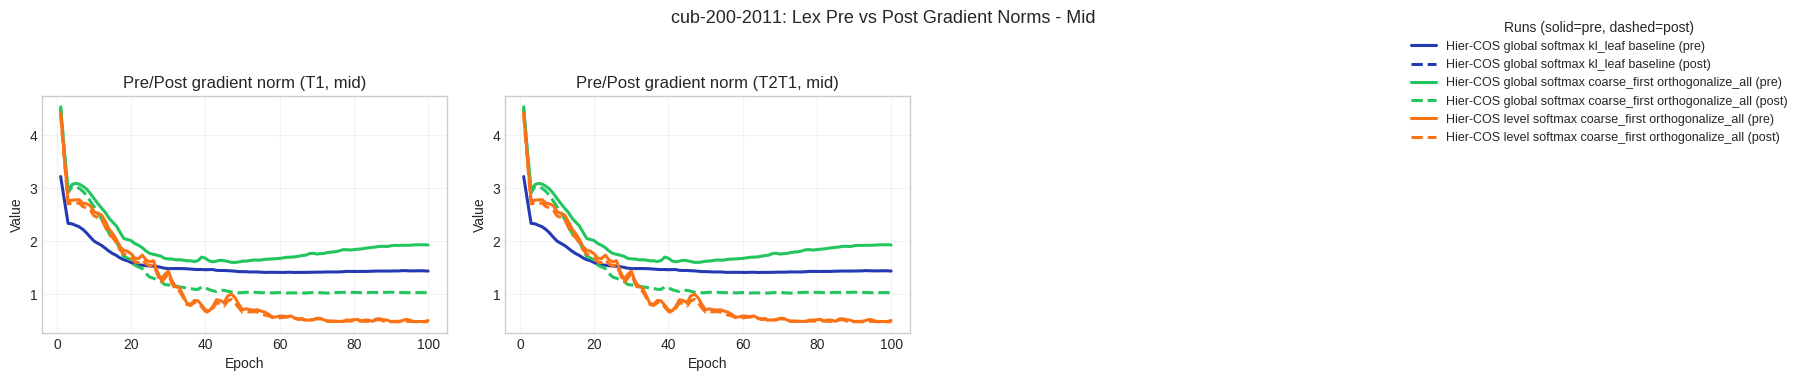

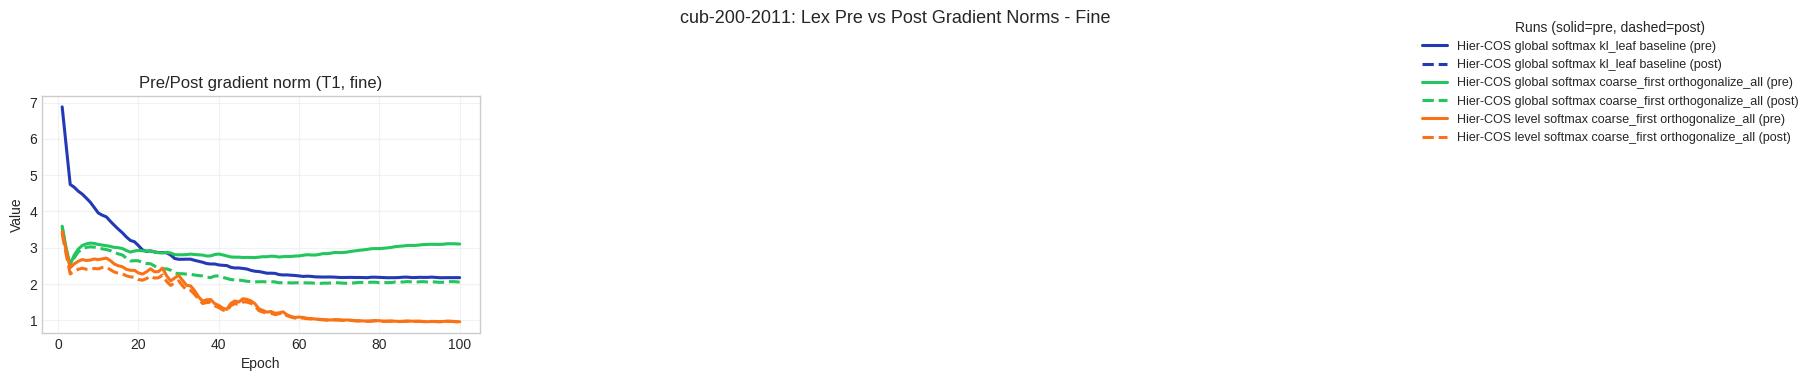

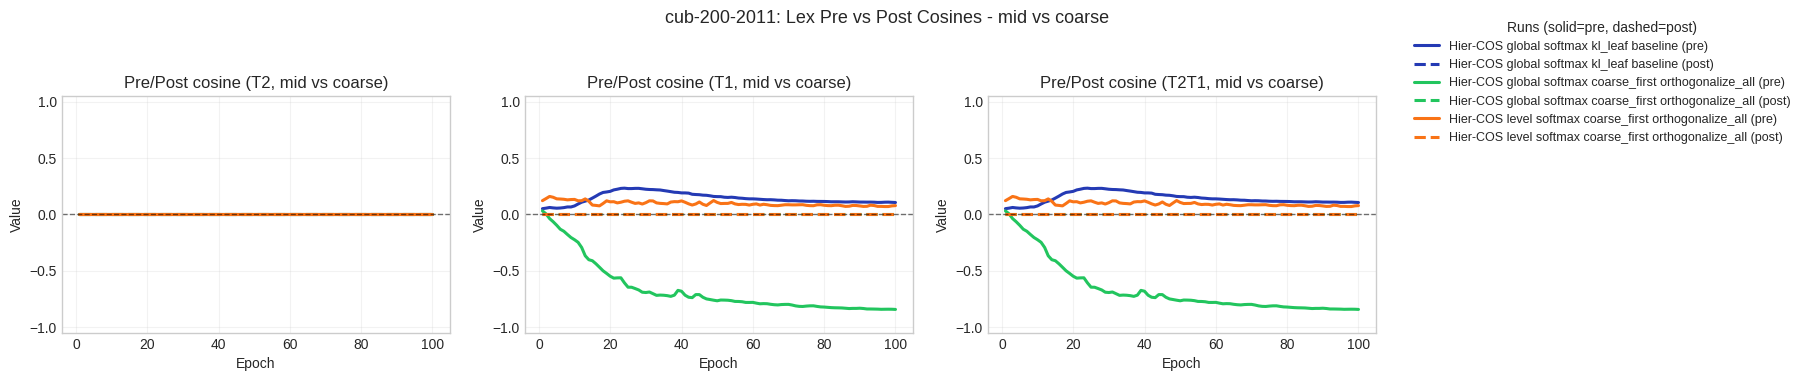

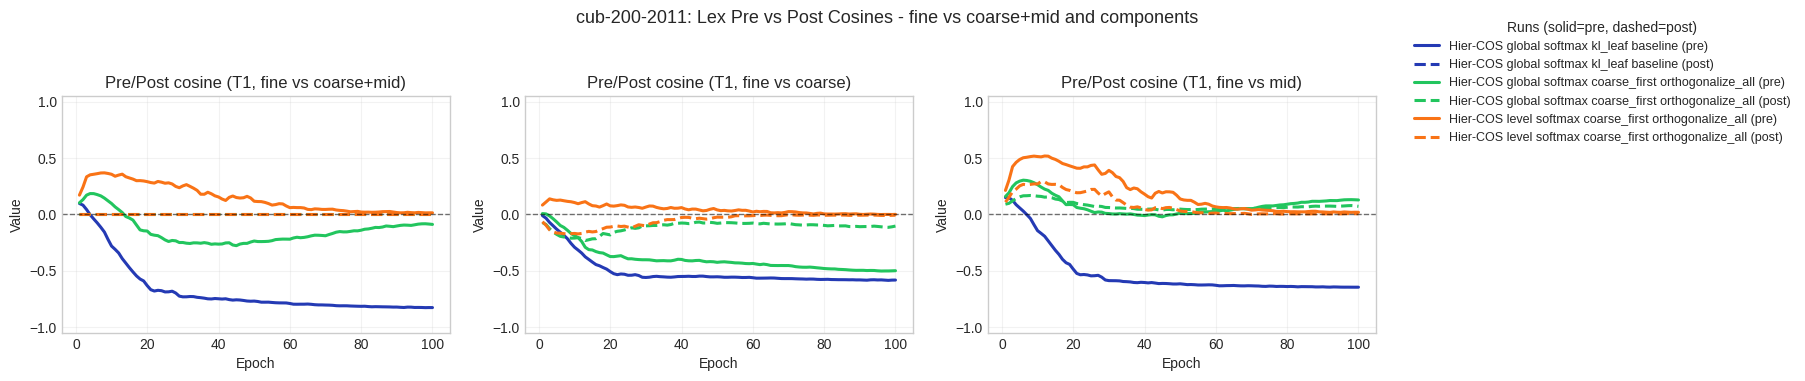

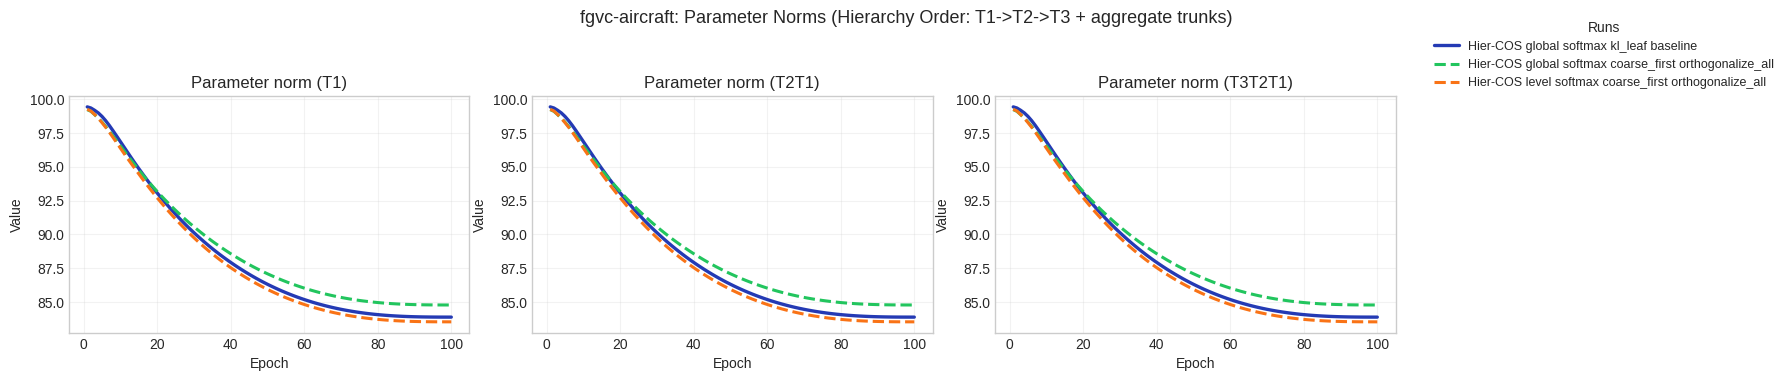

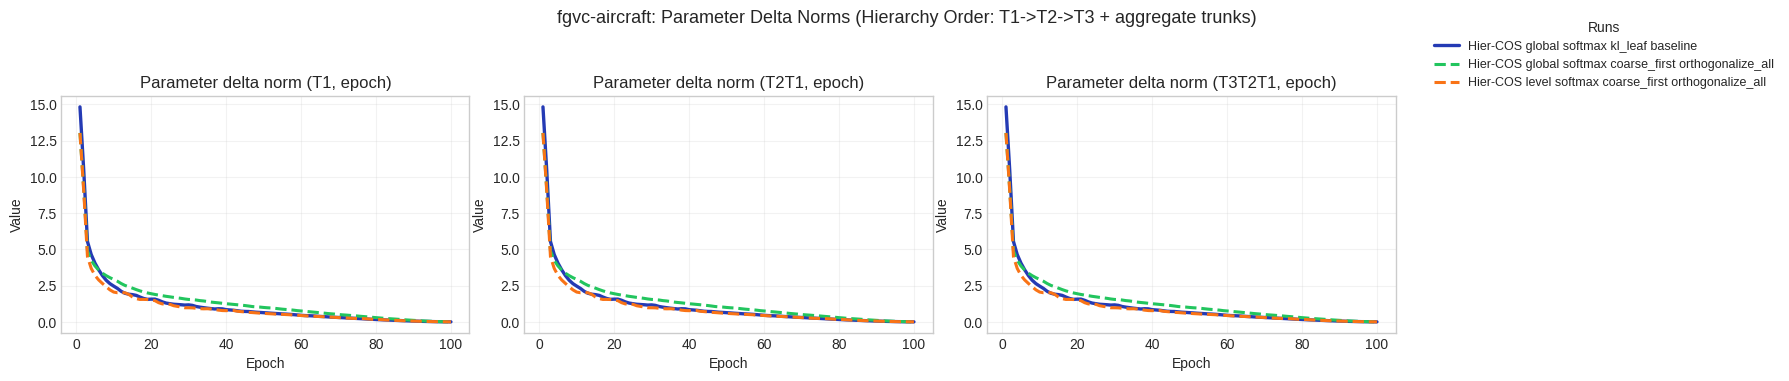

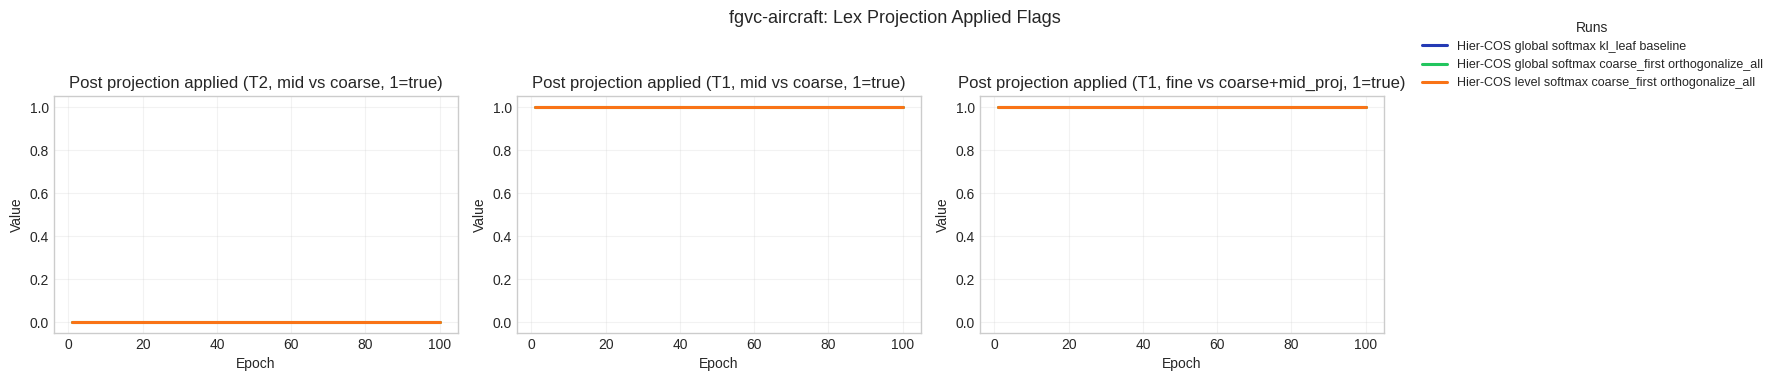

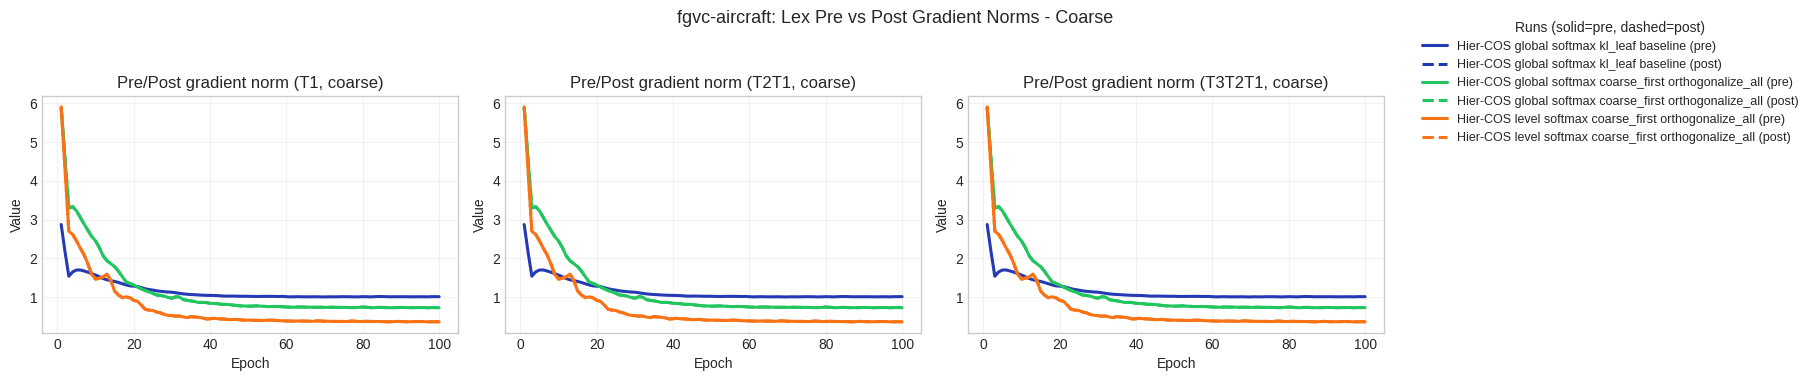

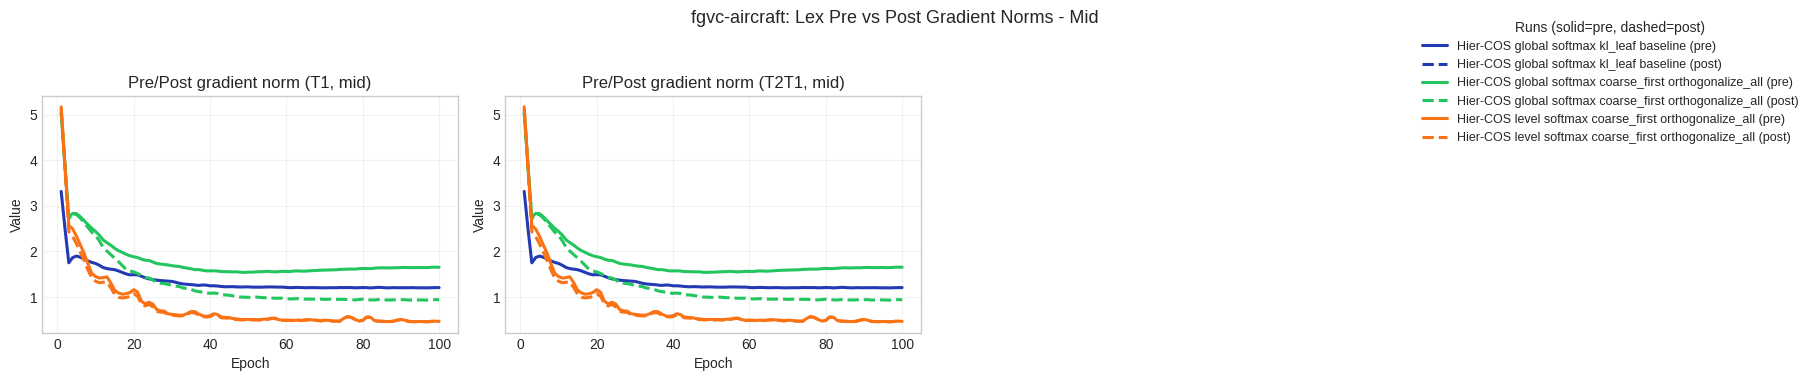

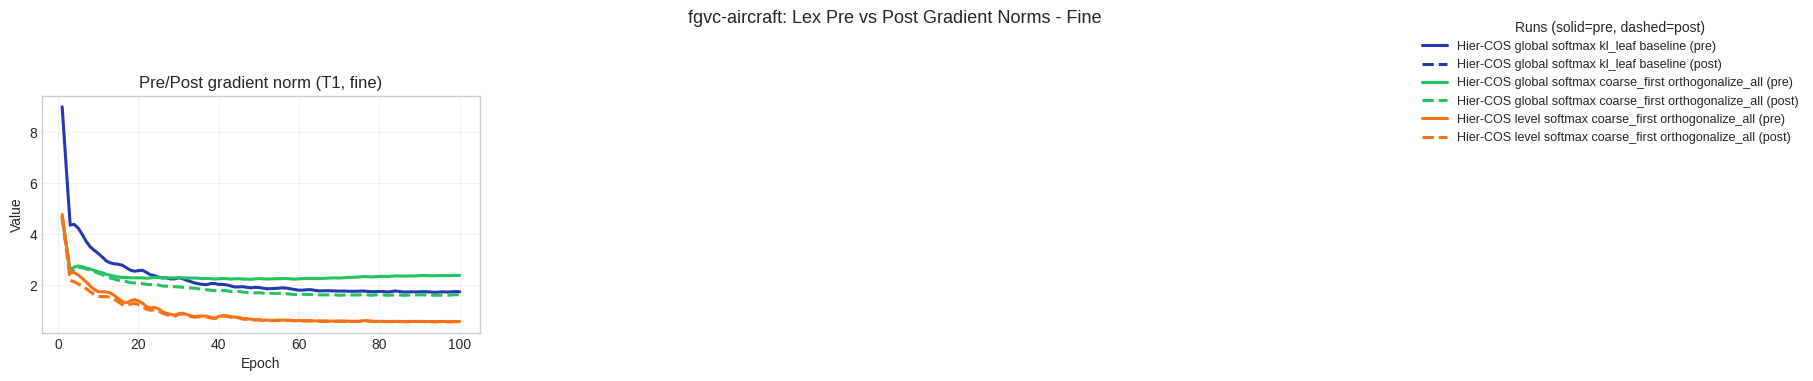

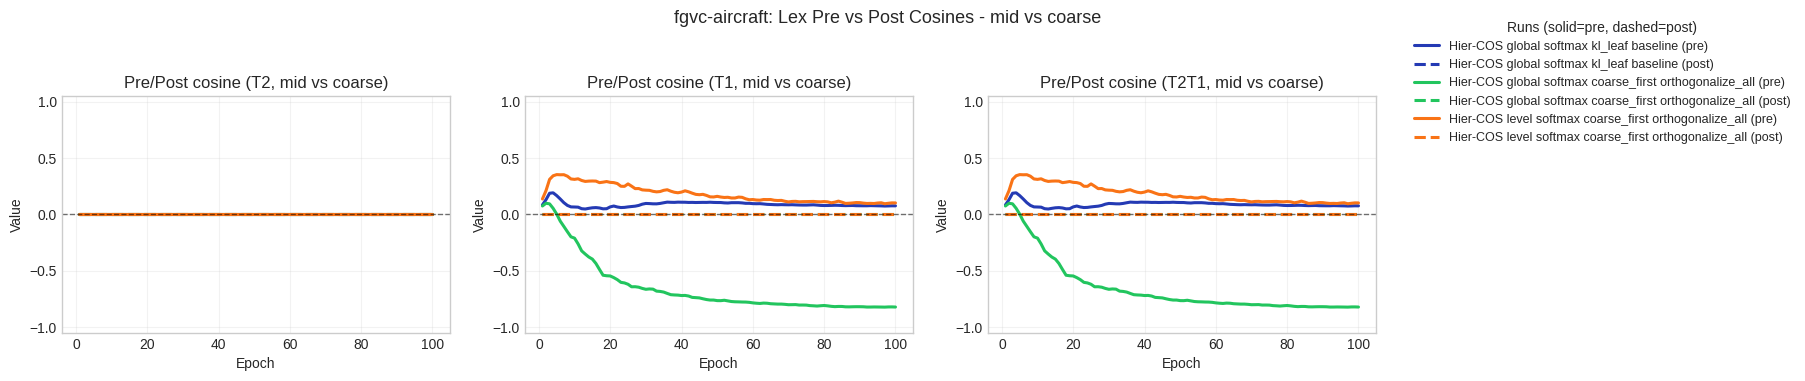

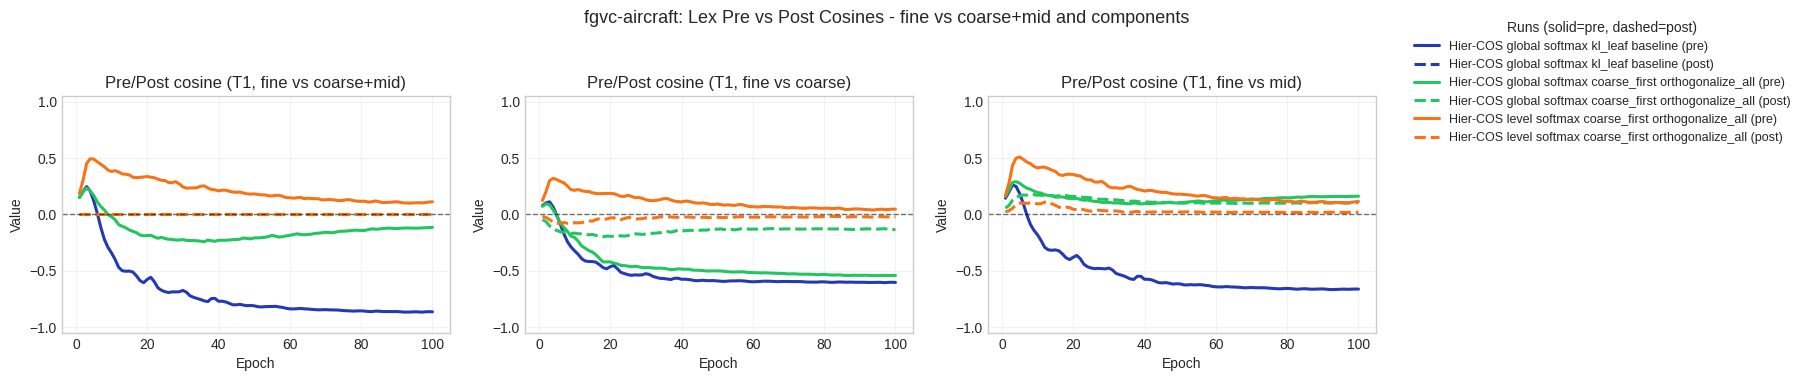

In [48]:
GRAD_SMOOTH_WINDOW = 2
SHOW_RAW_OVERLAY = False
RAW_ALPHA = 0.12
N_COLS = 3
LOG_SCALE_FOR_NORMS = False
AX_WIDTH = 6.0
AX_HEIGHT = 3.8
LEGEND_GUTTER_RATIO = 0.78
LEGEND_MAX_ROWS_PER_COL = 10

analysis.plot_gradient_diagnostics(
    smooth_window=GRAD_SMOOTH_WINDOW,
    show_raw_overlay=SHOW_RAW_OVERLAY,
    raw_alpha=RAW_ALPHA,
    n_cols=N_COLS,
    log_scale_for_norms=LOG_SCALE_FOR_NORMS,
    ax_width=AX_WIDTH,
    ax_height=AX_HEIGHT,
    legend_gutter_ratio=LEGEND_GUTTER_RATIO,
    legend_max_rows_per_col=LEGEND_MAX_ROWS_PER_COL,
)


Interpretation note:

- Large spikes in gradient norms indicate unstable update pressure for that subset/level path.
- If `grad_norm_t1_fine` collapses while `t1` coarse/mid stay high, fine supervision is not effectively reaching shared parameters.
- Negative cosine values indicate level conflict on the corresponding subset.
- `param_norm_*` is scale, `delta_param_norm_*` is per-epoch movement.
- In lex mode, projected cosines should move near 0 (orthogonality on the target mask).
- `post_projection_applied_* = 0` means the corresponding projection step was skipped for numerical safety.


## Per-Level Validation Accuracy (Top-Down and Independent)

Each level plot overlays both modes on the same axes:
- color = run
- line style = mode (`topdown` solid, `independent` dashed).

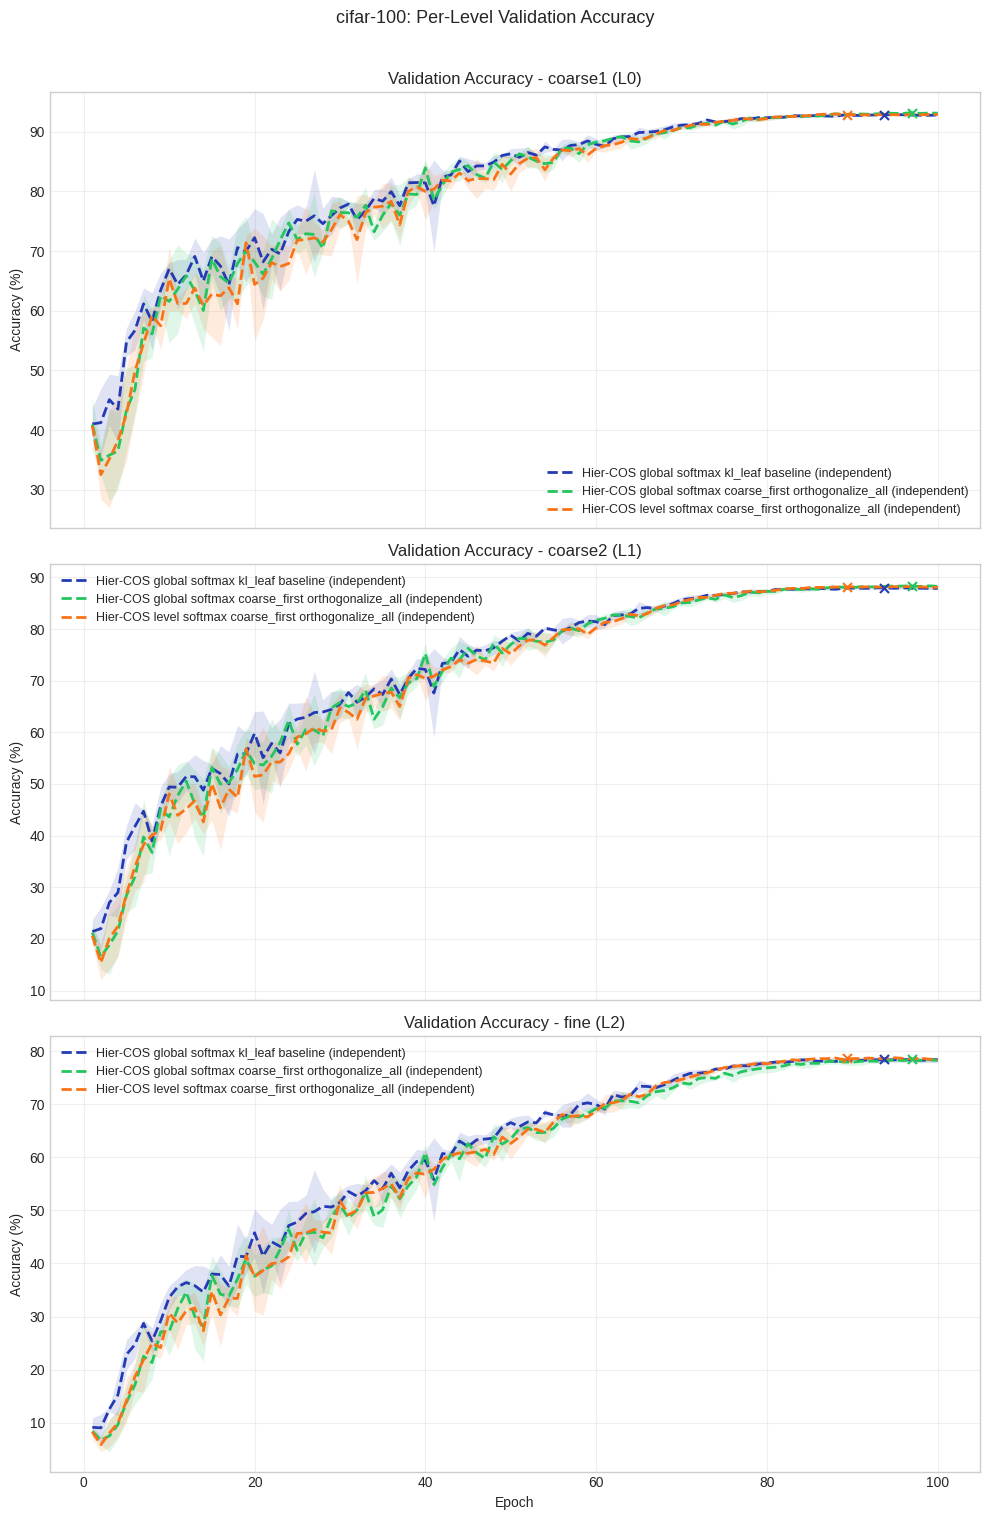

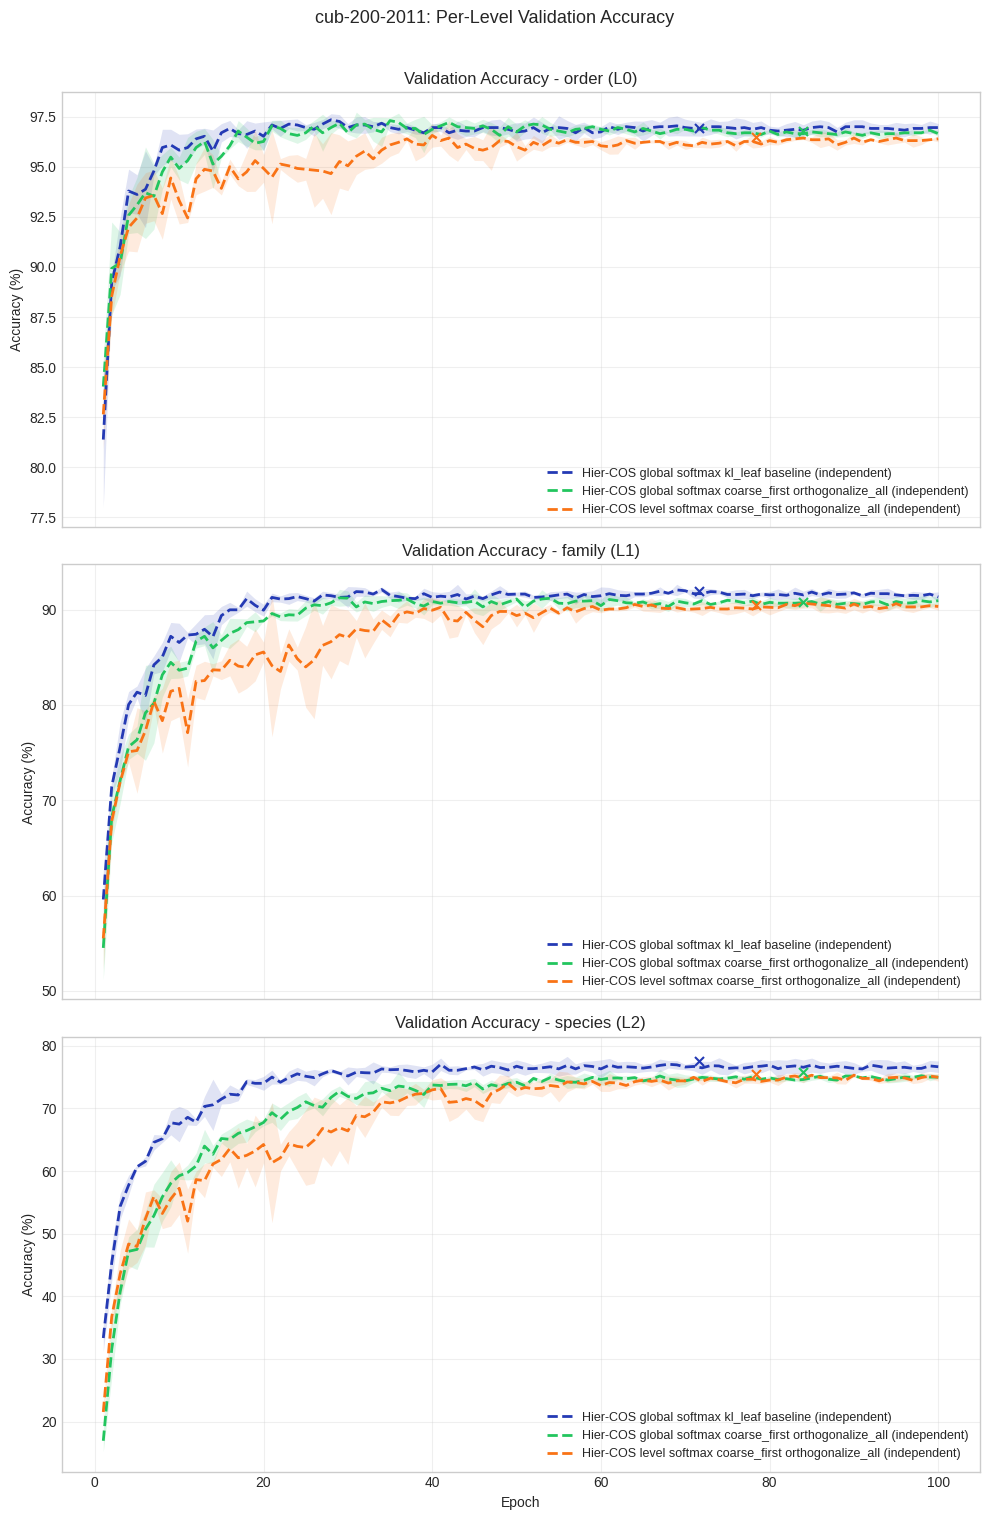

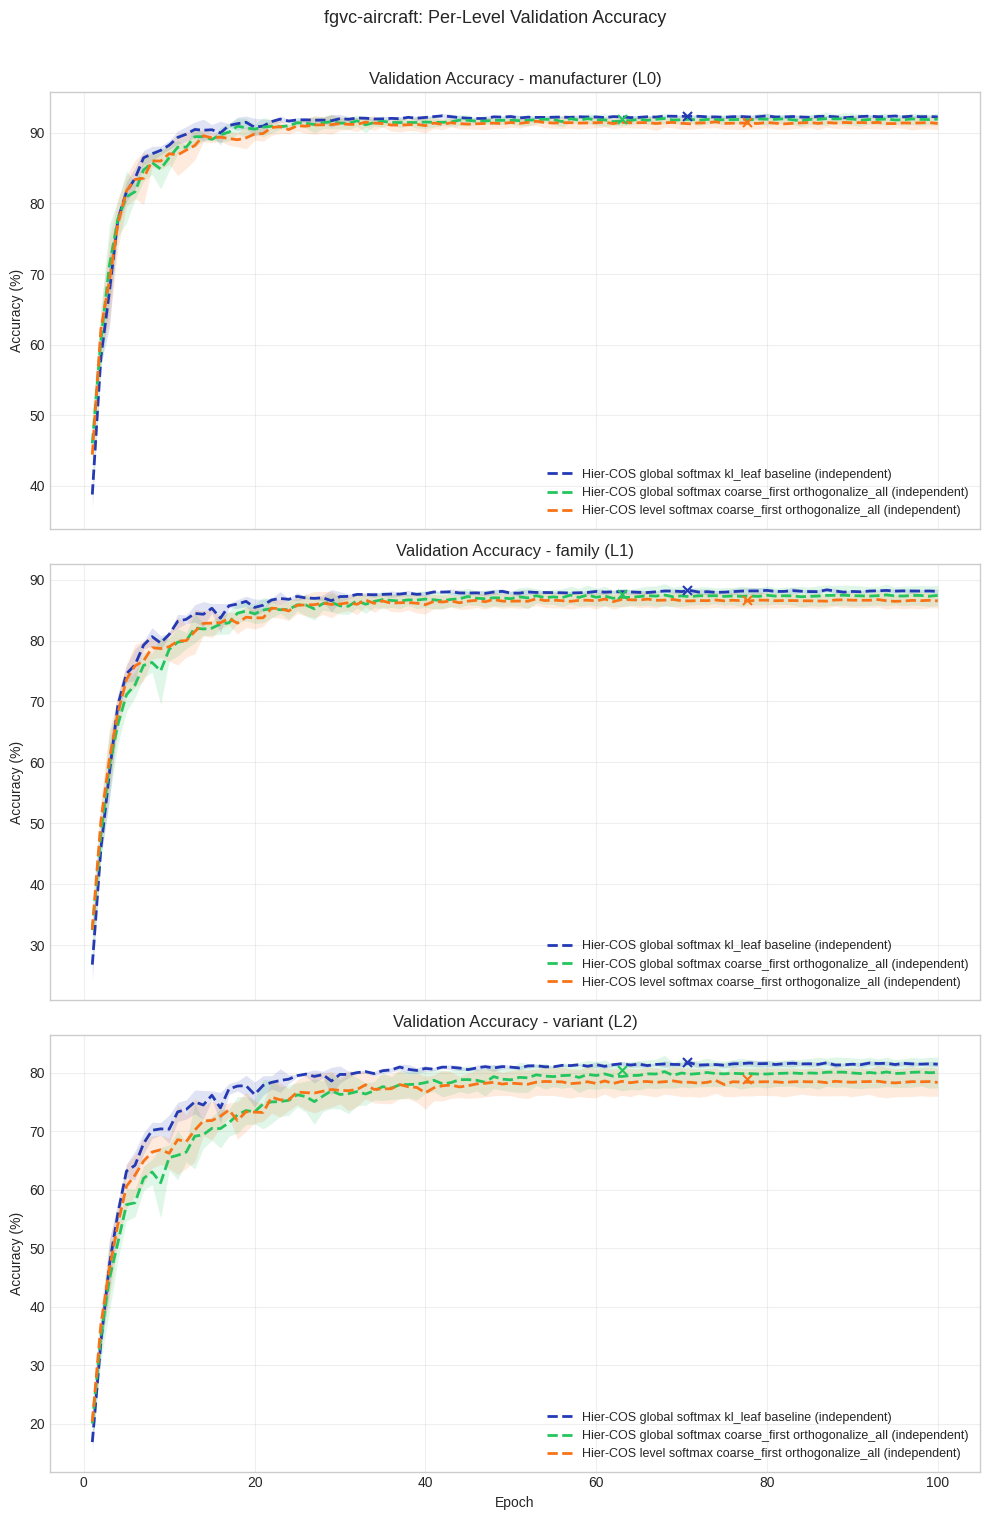

In [49]:
analysis.plot_per_level_validation_accuracy()


Interpretation note:
- In each subplot, solid vs dashed of the same color gives the top-down penalty/gain for that run.
- Across colors, you can compare runs within the same decoding mode by matching line style.
- Larger gaps at deeper levels usually have the strongest impact on final path metrics.

## Final Test Comparison Table

For each dataset, the table compares key test metrics for selected runs and reports deltas versus the first run listed for that dataset (typically the `kl_reg` baseline).


In [50]:
analysis.show_final_test_tables()


### Dataset: `cifar-100`
Baseline run: **Hier-COS global softmax kl_leaf baseline**

| Metric | Hier-COS global softmax kl_leaf baseline (n=3) | Hier-COS global softmax coarse_first orthogonalize_all (n=3) | Hier-COS level softmax coarse_first orthogonalize_all (n=3) |
|---|---:|---:|---:|
| Best epoch (Ind) | 93.7 ± 5.0 | 97.0 ± 2.0 | 93.0 ± 4.4 |
| FPA independent ↑ | <u>77.50% ± 0.15%</u> | 77.27% ± 0.24% (-0.23 pp) | **77.64% ± 0.28% (+0.14 pp)** |
| wAP independent ↑ | **80.05% ± 0.19%** | 79.81% ± 0.18% (-0.24 pp) | <u>80.05% ± 0.24% (-0.00 pp)</u> |
| TICE independent ↓ | 1.05% ± 0.04% | **0.44% ± 0.07% (-0.60 pp)** | <u>0.56% ± 0.10% (-0.48 pp)</u> |
| AHD independent ↓ | 0.444 ± 0.003 | **0.441 ± 0.002 (-0.004)** | <u>0.442 ± 0.003 (-0.002)</u> |
| Acc independent coarse1 (L0) ↑ | 91.34% ± 0.06% | **91.65% ± 0.10% (+0.31 pp)** | <u>91.35% ± 0.09% (+0.01 pp)</u> |
| Acc independent coarse2 (L1) ↑ | 86.86% ± 0.20% | **87.08% ± 0.06% (+0.23 pp)** | <u>86.90% ± 0.13% (+0.04 pp)</u> |
| Acc independent fine (L2) ↑ | **77.79% ± 0.20%** | 77.41% ± 0.23% (-0.37 pp) | <u>77.78% ± 0.30% (-0.01 pp)</u> |

### Dataset: `cub-200-2011`
Baseline run: **Hier-COS global softmax kl_leaf baseline**

| Metric | Hier-COS global softmax kl_leaf baseline (n=3) | Hier-COS global softmax coarse_first orthogonalize_all (n=3) | Hier-COS level softmax coarse_first orthogonalize_all (n=3) |
|---|---:|---:|---:|
| Best epoch (Ind) | 71.7 ± 16.3 | 84.0 ± 15.1 | 78.3 ± 20.2 |
| FPA independent ↑ | **76.06% ± 0.43%** | <u>74.10% ± 0.23% (-1.96 pp)</u> | 73.23% ± 0.78% (-2.83 pp) |
| wAP independent ↑ | **79.51% ± 0.34%** | <u>77.80% ± 0.23% (-1.71 pp)</u> | 77.07% ± 0.69% (-2.44 pp) |
| TICE independent ↓ | 0.60% ± 0.19% | **0.32% ± 0.02% (-0.28 pp)** | <u>0.58% ± 0.02% (-0.02 pp)</u> |
| AHD independent ↓ | **0.367 ± 0.006** | <u>0.391 ± 0.007 (+0.023)</u> | 0.407 ± 0.012 (+0.039) |
| Acc independent order (L0) ↑ | **96.83% ± 0.12%** | <u>96.68% ± 0.17% (-0.14 pp)</u> | 96.45% ± 0.27% (-0.38 pp) |
| Acc independent family (L1) ↑ | **90.48% ± 0.11%** | <u>90.16% ± 0.29% (-0.32 pp)</u> | 89.67% ± 0.36% (-0.81 pp) |
| Acc independent species (L2) ↑ | **76.30% ± 0.41%** | <u>74.22% ± 0.24% (-2.08 pp)</u> | 73.41% ± 0.80% (-2.88 pp) |

### Dataset: `fgvc-aircraft`
Baseline run: **Hier-COS global softmax kl_leaf baseline**

| Metric | Hier-COS global softmax kl_leaf baseline (n=3) | Hier-COS global softmax coarse_first orthogonalize_all (n=3) | Hier-COS level softmax coarse_first orthogonalize_all (n=3) |
|---|---:|---:|---:|
| Best epoch (Ind) | 70.7 ± 11.0 | 63.0 ± 8.7 | 77.7 ± 13.9 |
| FPA independent ↑ | **81.40% ± 0.52%** | <u>79.10% ± 1.94% (-2.30 pp)</u> | 78.10% ± 2.48% (-3.30 pp) |
| wAP independent ↑ | **85.44% ± 0.37%** | <u>83.84% ± 1.57% (-1.60 pp)</u> | 83.05% ± 1.96% (-2.39 pp) |
| TICE independent ↓ | 0.78% ± 0.13% | <u>0.59% ± 0.24% (-0.19 pp)</u> | **0.54% ± 0.09% (-0.24 pp)** |
| AHD independent ↓ | **0.384 ± 0.008** | <u>0.422 ± 0.040 (+0.039)</u> | 0.443 ± 0.051 (+0.060) |
| Acc independent manufacturer (L0) ↑ | **92.22% ± 0.05%** | <u>91.77% ± 0.81% (-0.45 pp)</u> | 91.18% ± 0.99% (-1.04 pp) |
| Acc independent family (L1) ↑ | **88.10% ± 0.33%** | <u>87.00% ± 1.38% (-1.10 pp)</u> | 86.50% ± 1.64% (-1.60 pp) |
| Acc independent variant (L2) ↑ | **81.55% ± 0.52%** | <u>79.26% ± 1.98% (-2.29 pp)</u> | 78.20% ± 2.48% (-3.35 pp) |

Interpretation note:
- Metrics are rows and runs are columns.
- Goal arrows are in metric names: `↑` means maximize, `↓` means minimize.
- Non-baseline run cells show `value (delta vs baseline)`.
- Bold cells mark the best run for each metric in the dataset table.
- Delta is computed as `run - baseline`.
